In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LogLocator
from matplotlib.colors import (ListedColormap, LinearSegmentedColormap,
                               Normalize, LogNorm, TwoSlopeNorm, to_rgb)
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats, signal, optimize, integrate
from pathlib import Path
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ----------------------------------------------------------------------------
# Font resolution
# ----------------------------------------------------------------------------
FONT_STACK = [
    'Helvetica Neue', 'HelveticaNeue', 'Helvetica',   # macOS
    'TeX Gyre Heros', 'Nimbus Sans', 'FreeSans',      # Helvetica metric clones
    'Arial', 'Liberation Sans',                       # Windows / Linux
    'DejaVu Sans',                                    # matplotlib's own fallback
]

def resolve_font(stack=FONT_STACK, verbose=True):
    '''Return the first font in `stack` that is actually installed.'''
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in stack:
        if name in have:
            if verbose and name != stack[0]:
                print(f'[style] "{stack[0]}" not found -> using "{name}"')
            elif verbose:
                print(f'[style] using "{name}"')
            return name
    if verbose:
        print('[style] nothing in the stack found -> DejaVu Sans')
    return 'DejaVu Sans'

ACTIVE_FONT = resolve_font()

# ----------------------------------------------------------------------------
# House style
# ----------------------------------------------------------------------------
def set_style(base=11, family=None, mathfont='cm', usetex=False,
              screen_dpi=140, save_dpi=600):
    '''
    Apply the group house style.

    base       : point size of tick labels. Axis labels are base+3.
                 Journals want >= 6 pt after reduction; 8-11 pt is the sweet spot.
    mathfont   : 'cm'   -> Computer Modern math (matches a LaTeX manuscript)
                 'stix' -> Times-like math
                 'dejavusans' / 'custom' -> sans-serif math (matches Helvetica)
    usetex     : True routes ALL text through a real LaTeX install. Prettiest
                 and most consistent, but slow and breaks on machines without
                 LaTeX. Keep False for exploration, flip True for final figures.
    save_dpi   : only affects raster elements (imshow, scatter with many points).
                 Vector output is resolution-independent.
    '''
    mpl.rcParams.update(mpl.rcParamsDefault)
    fam = family or ACTIVE_FONT
    mpl.rcParams.update({
        # --- typography ---
        'font.family'       : 'sans-serif',
        'font.sans-serif'   : [fam] + FONT_STACK,
        'mathtext.fontset'  : mathfont,
        'mathtext.default'  : 'it',
        'text.usetex'       : usetex,
        'font.size'         : base,
        'axes.labelsize'    : base + 3,
        'axes.titlesize'    : base + 1,
        'axes.titleweight'  : 'regular',
        'xtick.labelsize'   : base,
        'ytick.labelsize'   : base,
        'legend.fontsize'   : base - 1,
        'legend.title_fontsize': base - 1,

        # --- axes furniture ---
        'axes.linewidth'    : 0.8,
        'axes.labelpad'     : 4.0,
        'axes.spines.top'   : False,
        'axes.spines.right' : False,
        'axes.axisbelow'    : True,
        'axes.grid'         : False,
        'grid.linewidth'    : 0.5,
        'grid.alpha'        : 0.35,

        # --- ticks: outward, minor ticks on ---
        'xtick.direction'   : 'out',   'ytick.direction'   : 'out',
        'xtick.major.size'  : 3.5,     'ytick.major.size'  : 3.5,
        'xtick.major.width' : 0.8,     'ytick.major.width' : 0.8,
        'xtick.minor.size'  : 2.0,     'ytick.minor.size'  : 2.0,
        'xtick.minor.width' : 0.6,     'ytick.minor.width' : 0.6,
        'xtick.major.pad'   : 3.0,     'ytick.major.pad'   : 3.0,

        # --- data elements ---
        'lines.linewidth'   : 1.4,
        'lines.markersize'  : 4.5,
        'lines.markeredgewidth': 0.6,
        'lines.solid_capstyle' : 'round',
        'patch.linewidth'   : 0.6,
        'errorbar.capsize'  : 2.5,
        'image.cmap'        : 'viridis',
        'image.interpolation': 'nearest',

        # --- legend ---
        'legend.frameon'      : False,
        'legend.handlelength' : 1.5,
        'legend.handletextpad': 0.5,
        'legend.labelspacing' : 0.30,
        'legend.borderpad'    : 0.2,
        'legend.columnspacing': 1.0,

        # --- figure / export ---
        'figure.facecolor'  : 'white',
        'axes.facecolor'    : 'white',
        'figure.dpi'        : screen_dpi,   # on-screen preview only
        'savefig.dpi'       : save_dpi,     # written files
        'savefig.bbox'      : 'tight',
        'savefig.pad_inches': 0.02,
        'savefig.facecolor' : 'white',
        'pdf.fonttype'      : 42,     # TrueType -> editable text in Illustrator
        'ps.fonttype'       : 42,
        'svg.fonttype'      : 'none', # keep <text> elements, do not outline
        'pdf.compression'   : 6,
    })

set_style()

# ----------------------------------------------------------------------------
# Journal column widths (inches). Draw at the size you will print at.
# ----------------------------------------------------------------------------
W = {
    'prl_single' : 3.375,   # Phys. Rev. Lett. / APS single column
    'prl_double' : 6.75,
    'nature_1col': 3.504,   # 89 mm
    'nature_2col': 7.205,   # 183 mm
    'pnas_1col'  : 3.42,
    'pnas_2col'  : 7.0,
    'elsevier_1col': 3.543, # 90 mm
    'elsevier_2col': 7.480, # 190 mm
    'jfm'        : 5.31,    # J. Fluid Mech. text width
    'beamer'     : 4.5,
}
print(f'[style] active font: {ACTIVE_FONT}')

[style] using "Helvetica Neue"
[style] active font: Helvetica Neue


In [3]:
fig_folder = "./figures"

# MODIFIED EXPERIMENT



In [22]:

import numpy as np


def generate_samples(r, N=50000, T=20):
    """
    Generate N independent AR(1) trajectories of length T.

    Each trajectory X^(n) = (x_0, ..., x_{T-1})
    is treated as one vector in R^T.
    """

    # Critical point: r_c = 0
    # a(r) -> 1 as r -> 0
    a = np.exp(-r)

    # Relaxation time
    tau = -1.0 / np.log(a)

    X = np.zeros((N, T))

    # Generate independent trajectories
    X[:, 0] = np.random.randn(N)

    for t in range(1, T):
        X[:, t] = a * X[:, t-1] + np.random.randn(N)

    return X, tau



In [23]:

def covariance(r, N=50000, T=20):
    X, tau = generate_samples(r, N=N, T=T)

    # Rows = independent trajectories
    # Columns = time coordinates
    Sigma = np.cov(X, rowvar=False)

    return Sigma, tau


In [24]:

r_list = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 5e-3, 1e-3, 5e-4, 1e-4]


In [25]:

for r in r_list:

    Sigma, tau = covariance(r)

    eigvals = np.linalg.eigvalsh(Sigma)

    print(
        f"r={r:.3g}, "
        f"tau={tau:.2f}, "
        f"lambda_max={eigvals[-1]:.3f}, "
        f"lambda_2={eigvals[-2]:.3f}"
    )


r=0.5, tau=2.00, lambda_max=5.985, lambda_2=4.926
r=0.2, tau=5.00, lambda_max=21.854, lambda_2=11.237
r=0.1, tau=10.00, lambda_max=48.993, lambda_2=15.530
r=0.05, tau=20.00, lambda_max=84.171, lambda_2=17.471
r=0.02, tau=50.00, lambda_max=125.325, lambda_2=18.514
r=0.01, tau=100.00, lambda_max=147.364, lambda_2=18.816
r=0.005, tau=200.00, lambda_max=157.689, lambda_2=18.874
r=0.001, tau=1000.00, lambda_max=167.604, lambda_2=18.813
r=0.0005, tau=2000.00, lambda_max=170.612, lambda_2=18.885
r=0.0001, tau=10000.00, lambda_max=170.229, lambda_2=18.794


In [26]:

for r in r_list:

    Sigma, tau = covariance(r)

    eigvals, eigvecs = np.linalg.eigh(Sigma)

    lam1 = eigvals[-1]
    lam2 = eigvals[-2]

    explained = lam1 / np.sum(eigvals)

    print(
        f"r={r:.3g}, "
        f"tau={tau:.2f}, "
        f"lambda1/lambda2={lam1/lam2:.2f}, "
        f"variance fraction={explained:.3f}"
    )

Sigma_ref, tau = covariance(1e-4)

evals, evecs = np.linalg.eigh(Sigma_ref)
v_ref = evecs[:, -1]


r=0.5, tau=2.00, lambda1/lambda2=1.21, variance fraction=0.195
r=0.2, tau=5.00, lambda1/lambda2=1.94, variance fraction=0.401
r=0.1, tau=10.00, lambda1/lambda2=3.17, variance fraction=0.570
r=0.05, tau=20.00, lambda1/lambda2=4.84, variance fraction=0.688
r=0.02, tau=50.00, lambda1/lambda2=6.87, variance fraction=0.764
r=0.01, tau=100.00, lambda1/lambda2=7.77, variance fraction=0.787
r=0.005, tau=200.00, lambda1/lambda2=8.28, variance fraction=0.799
r=0.001, tau=1000.00, lambda1/lambda2=8.77, variance fraction=0.807
r=0.0005, tau=2000.00, lambda1/lambda2=8.80, variance fraction=0.809
r=0.0001, tau=10000.00, lambda1/lambda2=9.10, variance fraction=0.813


In [27]:

for r in r_list:

    Sigma, tau = covariance(r)

    evals, evecs = np.linalg.eigh(Sigma)
    v = evecs[:, -1]

    overlap = abs(v @ v_ref)

    print(
        f"r={r:.3g}, "
        f"tau={tau:.2f}, "
        f"overlap={overlap:.4f}"
    )

r=0.5, tau=2.00, overlap=0.9103
r=0.2, tau=5.00, overlap=0.9641
r=0.1, tau=10.00, overlap=0.9843
r=0.05, tau=20.00, overlap=0.9954
r=0.02, tau=50.00, overlap=0.9992
r=0.01, tau=100.00, overlap=0.9998
r=0.005, tau=200.00, overlap=0.9999
r=0.001, tau=1000.00, overlap=1.0000
r=0.0005, tau=2000.00, overlap=1.0000
r=0.0001, tau=10000.00, overlap=1.0000


# <fieldset>COMPUTATIONAL RESULTS</fieldset>

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)
# font = {
#         'weight' : 'light',
#         'size'   : 16}

# mpl.rc('font', **font)
# plt.rc("xtick", labelsize="medium")
# rc = {"mathtext.fontset" : "cm"}
# plt.rcParams.update(rc)

# =====================================================
# Configuration
# =====================================================

N_train = 50000

nu_list = [ 0.35,0.55, 0.75]

Delta_list = np.logspace(-6, -3, 20)

degree_list = [
    2,
    4,
    6,
    8,
    10,
    16
]

r_min = -2.0
r_max = 2.0

N_plot = 20000

# =====================================================
# Critical function
# =====================================================

def lam(r, nu):
    return np.abs(r) ** (-nu)

def g(r, nu):
    return np.abs(r)**nu/(1.0 + np.abs(r)**nu)

# =====================================================
# Main sweep
# =====================================================

results = []

for nu in nu_list:

    for Delta in Delta_list:

        # ---------------------------
        # Training samples
        # ---------------------------

        r_left = np.random.uniform(
            r_min,
            -Delta/2,
            N_train // 2
        )

        r_right = np.random.uniform(
            Delta/2,
            r_max,
            N_train // 2
        )

        r_train = np.concatenate(
            [r_left, r_right]
        )

        y_train = g(r_train, nu)

        # score-loss-inspired weight
        weights = 1.0 + lam(r_train, nu)

        # evaluation grid

        r_plot = np.linspace(
            r_min,
            r_max,
            N_plot
        )

        y_true = g(r_plot, nu)

        train_mask = np.abs(r_plot) > Delta/2
        crit_mask = np.abs(r_plot) < Delta/2

        for degree in degree_list:

            # -----------------------
            # Fit polynomial
            # -----------------------

            coeffs = np.polyfit(
                r_train,
                y_train,
                degree,
                w=np.sqrt(weights)
            )

            leading_coeff = coeffs[0]
            const_coeff = coeffs[-1]

            poly = np.poly1d(coeffs)

            y_pred = poly(r_plot)

            plot_weights = 1 + lam(r_plot, nu)

            # -----------------------
            # Errors
            # -----------------------

            train_mse = np.mean(
                plot_weights[train_mask] * (
                    y_true[train_mask]
                    - y_pred[train_mask]
                ) ** 2
            )

            r_crit = np.linspace(-Delta/2, Delta/2, N_plot)

            critical_mse = np.mean(
                (1 + lam(r_crit, nu)) * (
                    g(r_crit, nu)
                    - poly(r_crit)
                )**2
            )

            gap_ratio = (
                critical_mse
                / train_mse
            )

            results.append(
                {
                    "nu": nu,
                    "Delta": Delta,
                    "degree": degree,
                    "train_mse": train_mse,
                    "critical_mse": critical_mse,
                    "gap_ratio": gap_ratio,
                    "coeffs": coeffs.copy()
                }
            )
        # plt.figure()
        # plt.plot(r_plot,y_true)
        # plt.plot(r_plot, y_pred)
        # # plt.axvspan(-Delta/2,Delta/2, alpha = 0.3, label = 'excised gap')
        # # plt.legend()
        # # plt.xlim(-Delta*100, Delta * 100)
        # plt.xlabel('r')
        # plt.ylabel('g(r)')
        # plt.title(fr'$\Delta$:{Delta:.2e}, $\nu$:{nu:.2e}, K:{degree}')
        # plt.show()

# =====================================================
# Print table
# =====================================================

for r in results:

    print(
        f"nu={r['nu']:4.2f} "
        f"Delta={r['Delta']:.3e} "
        f"K={r['degree']:2d} "
        f"train={r['train_mse']:.3e} "
        f"critical={r['critical_mse']:.3e} "
        f"ratio={r['gap_ratio']:.3e}"
        f"coeff = {r['coeffs']}"
    )

nu=0.35 Delta=1.000e-06 K= 2 train=9.900e-03 critical=3.517e+01 ratio=3.553e+03coeff = [6.34805020e-02 1.18441907e-04 3.80815918e-01]
nu=0.35 Delta=1.000e-06 K= 4 train=6.229e-03 critical=2.855e+01 ratio=4.583e+03coeff = [-3.45572466e-02 -4.77936454e-05  1.77301864e-01  7.47738300e-05
  3.43481532e-01]
nu=0.35 Delta=1.000e-06 K= 6 train=4.485e-03 critical=2.455e+01 ratio=5.474e+03coeff = [ 2.36851023e-02  7.99194265e-06 -1.60798420e-01  1.39196214e-05
  3.37550832e-01 -9.54505270e-05  3.18846475e-01]
nu=0.35 Delta=1.000e-06 K= 8 train=3.475e-03 critical=2.181e+01 ratio=6.276e+03coeff = [-1.79997300e-02 -5.75088593e-05  1.56034038e-01  3.47391303e-04
 -4.58369655e-01 -5.40784114e-04  5.42411747e-01  1.25510215e-04
  3.00724429e-01]
nu=0.35 Delta=1.000e-06 K=10 train=2.818e-03 critical=1.978e+01 ratio=7.019e+03coeff = [ 1.44466967e-02  1.08853112e-05 -1.53273472e-01 -1.56286202e-04
  5.93929652e-01  6.89264424e-04 -1.02557453e+00 -1.09144921e-03
  7.89245971e-01  4.52849659e-04  2.865942

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


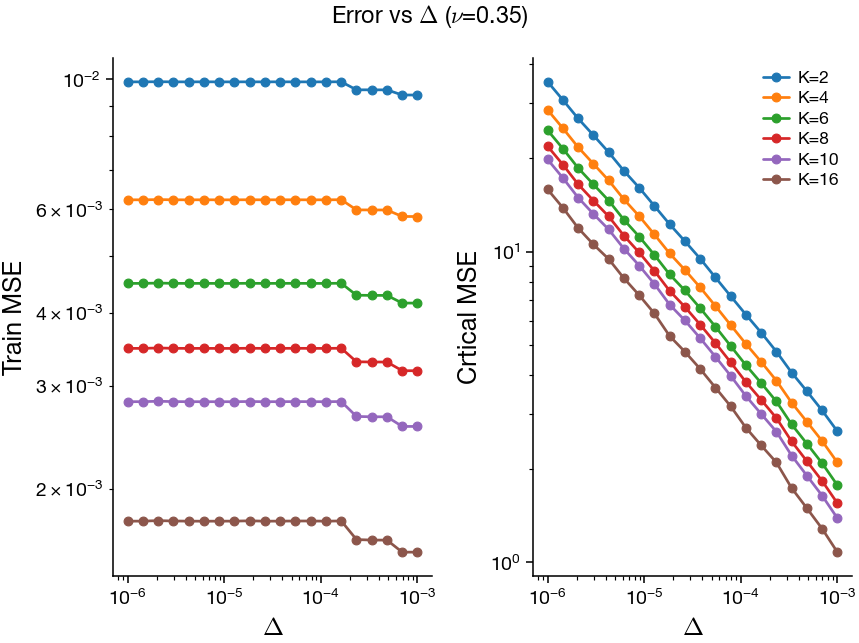

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


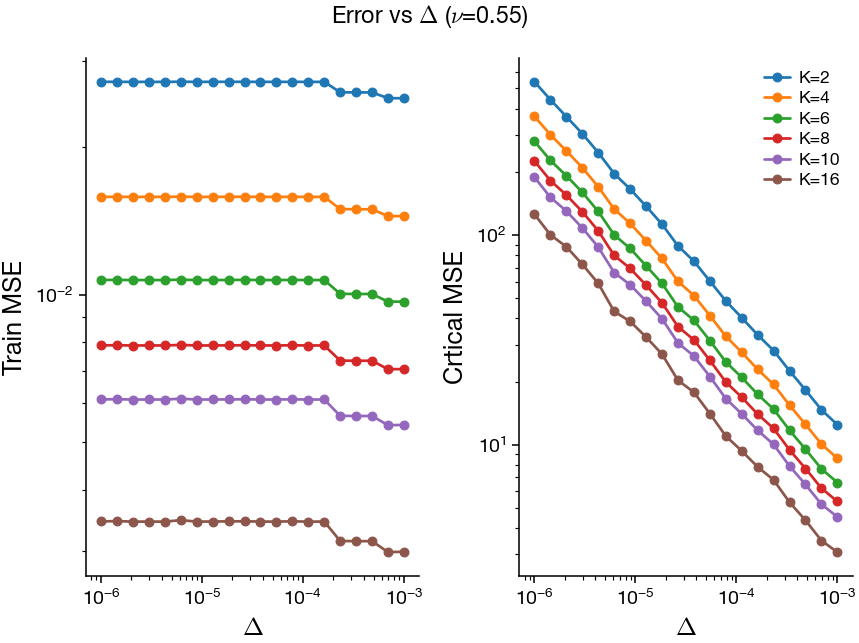

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


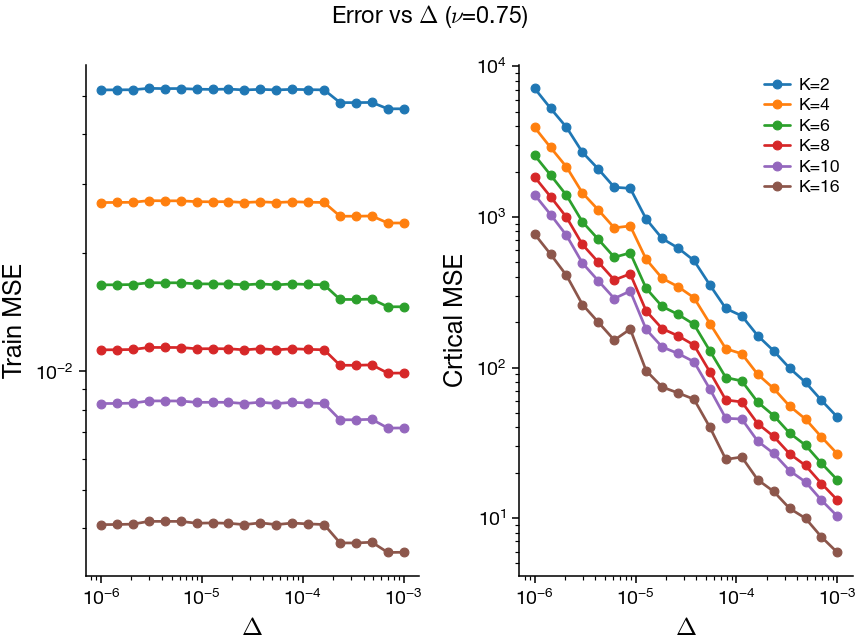

In [ ]:
#@title Error vs Delta (Error is calculated in the untrained region only)

for nu in nu_list:

    # plt.figure()
    fig, ax = plt.subplots(nrows=1, ncols=2, layout='tight')

    for degree in degree_list:

        xs = []
        ys1 = []
        ys2 = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys1.append(r["train_mse"])
                ys2.append(r["critical_mse"])


        ax[0].loglog(
            xs,
            ys1,
            marker = "o",
            label = f"K={degree}"
        )

        ax[1].loglog(
            xs,
            ys2,
            marker="o",
            label=f"K={degree}"
        )

    fig.suptitle(
        fr"Error vs $\Delta$ ($\nu$={nu})"
    )
    ax[0].set_xlabel(r"$\Delta$")
    ax[1].set_xlabel(r"$\Delta$")

    ax[0].set_ylabel("Train MSE")
    ax[1].set_ylabel("Crtical MSE")
    plt.legend()
    # plt.savefig(f"{fig_folder}/critical_error_v_delta.pdf")
    plt.show()

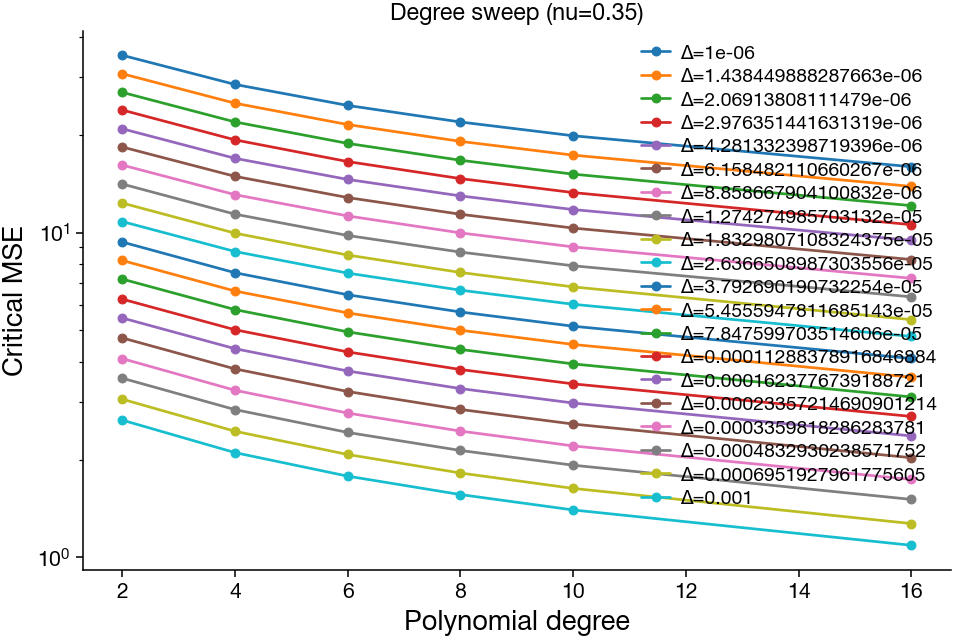

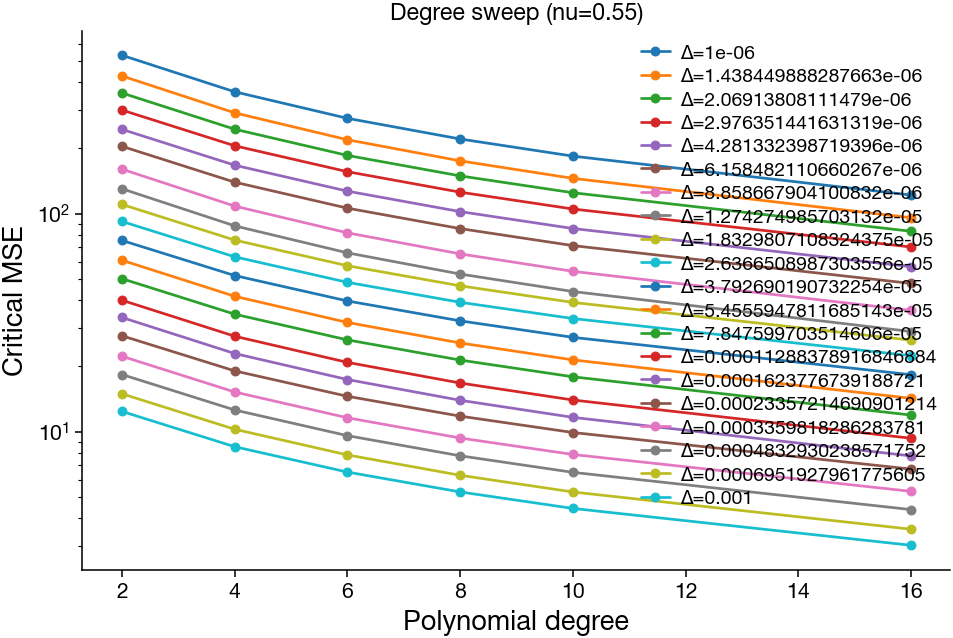

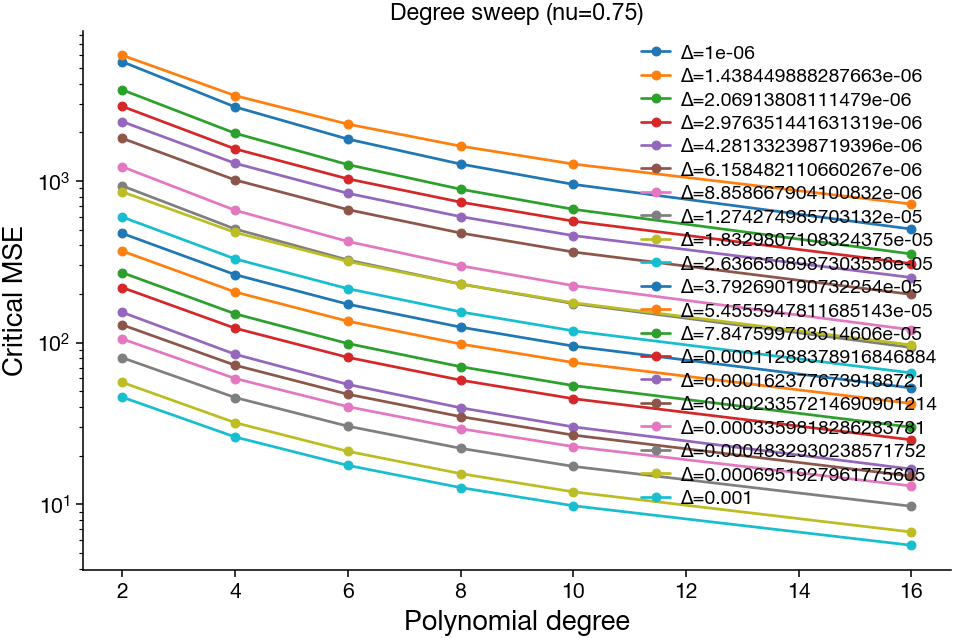

In [31]:
#@title Error vs degree k (Error is calculated in the untrained region only)

for nu in nu_list:

    plt.figure(figsize= (8,5))

    for Delta in Delta_list:

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["Delta"] == Delta
            ):
                xs.append(r["degree"])
                ys.append(r["critical_mse"])

        plt.semilogy(
            xs,
            ys,
            marker="o",
            label=f"Δ={Delta}"
        )

    plt.xlabel("Polynomial degree")
    plt.ylabel("Critical MSE")
    plt.title(
        f"Degree sweep (nu={nu})"
    )
    plt.legend()
    plt.show()

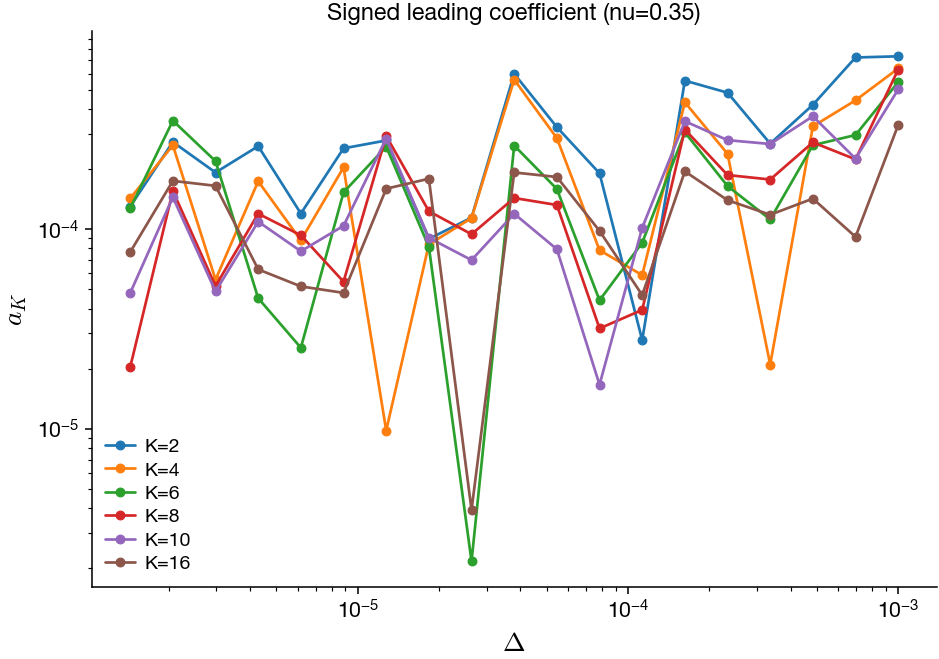

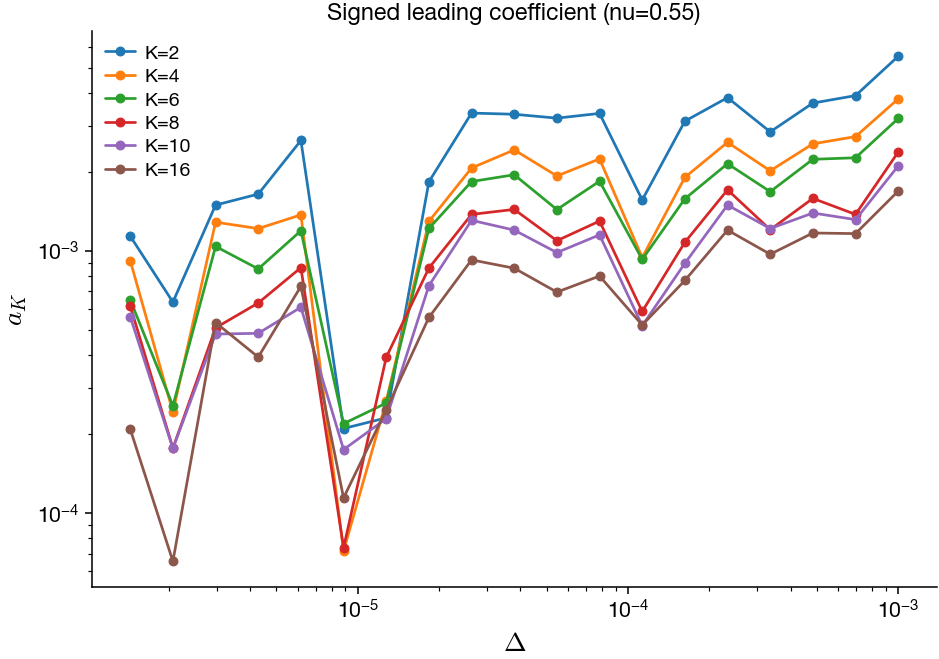

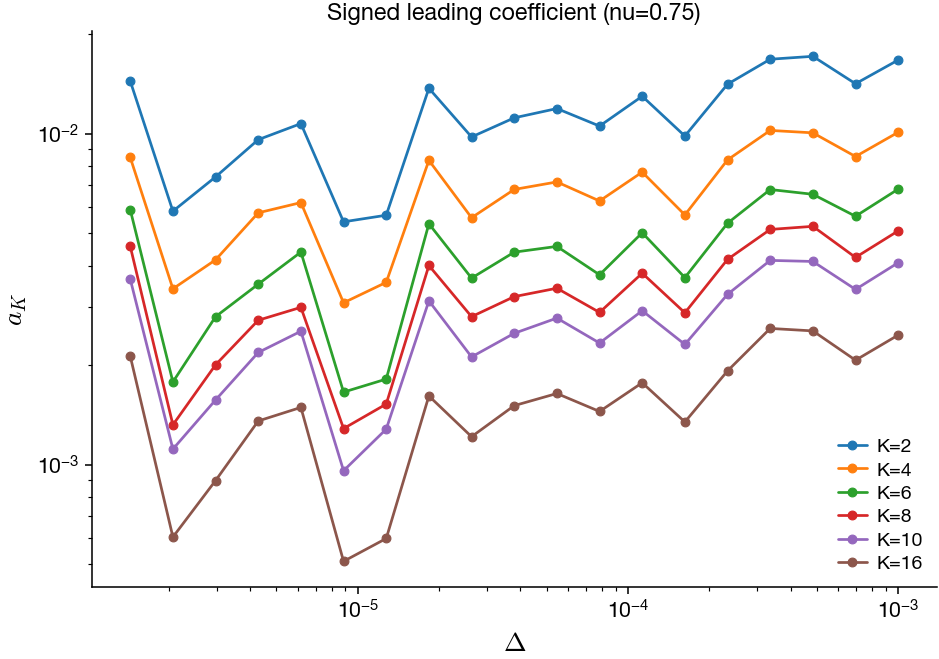

In [32]:
#@title a_k vs Delta

for nu in nu_list:

    plt.figure(figsize=(7,5))

    for degree in degree_list:

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(r["coeffs"][0])

        order = np.argsort(xs)

        xs = np.array(xs)[order]
        ys = np.array(np.abs(ys))[order]
        a_inf = ys[0]      # smallest Delta approximation

        corr = np.abs(ys - a_inf)

        plt.loglog(
            xs[1:],
            corr[1:],
            marker="o",
            label=f"K={degree}"
        )

    plt.xlabel(r"$\Delta$")
    plt.ylabel(r"$a_K$")
    plt.title(
        f"Signed leading coefficient (nu={nu})"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

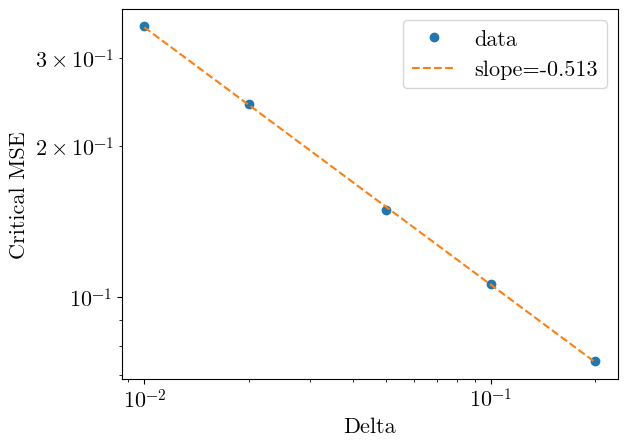

In [22]:
nu = 0.45
degree = 8

xs = []
ys = []

for r in results:

    if (
        r["nu"] == nu
        and r["degree"] == degree
    ):
        xs.append(r["Delta"])
        ys.append(r["critical_mse"])

xs = np.array(xs)
ys = np.array(ys)

alpha, b = np.polyfit(
    np.log(xs),
    np.log(ys),
    1
)

fit_curve = np.exp(b) * xs**alpha

plt.figure()
plt.loglog(xs, ys, "o", label="data")
plt.loglog(
    xs,
    fit_curve,
    "--",
    label=f"slope={alpha:.3f}"
)
plt.xlabel("Delta")
plt.ylabel("Critical MSE")
plt.legend()
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


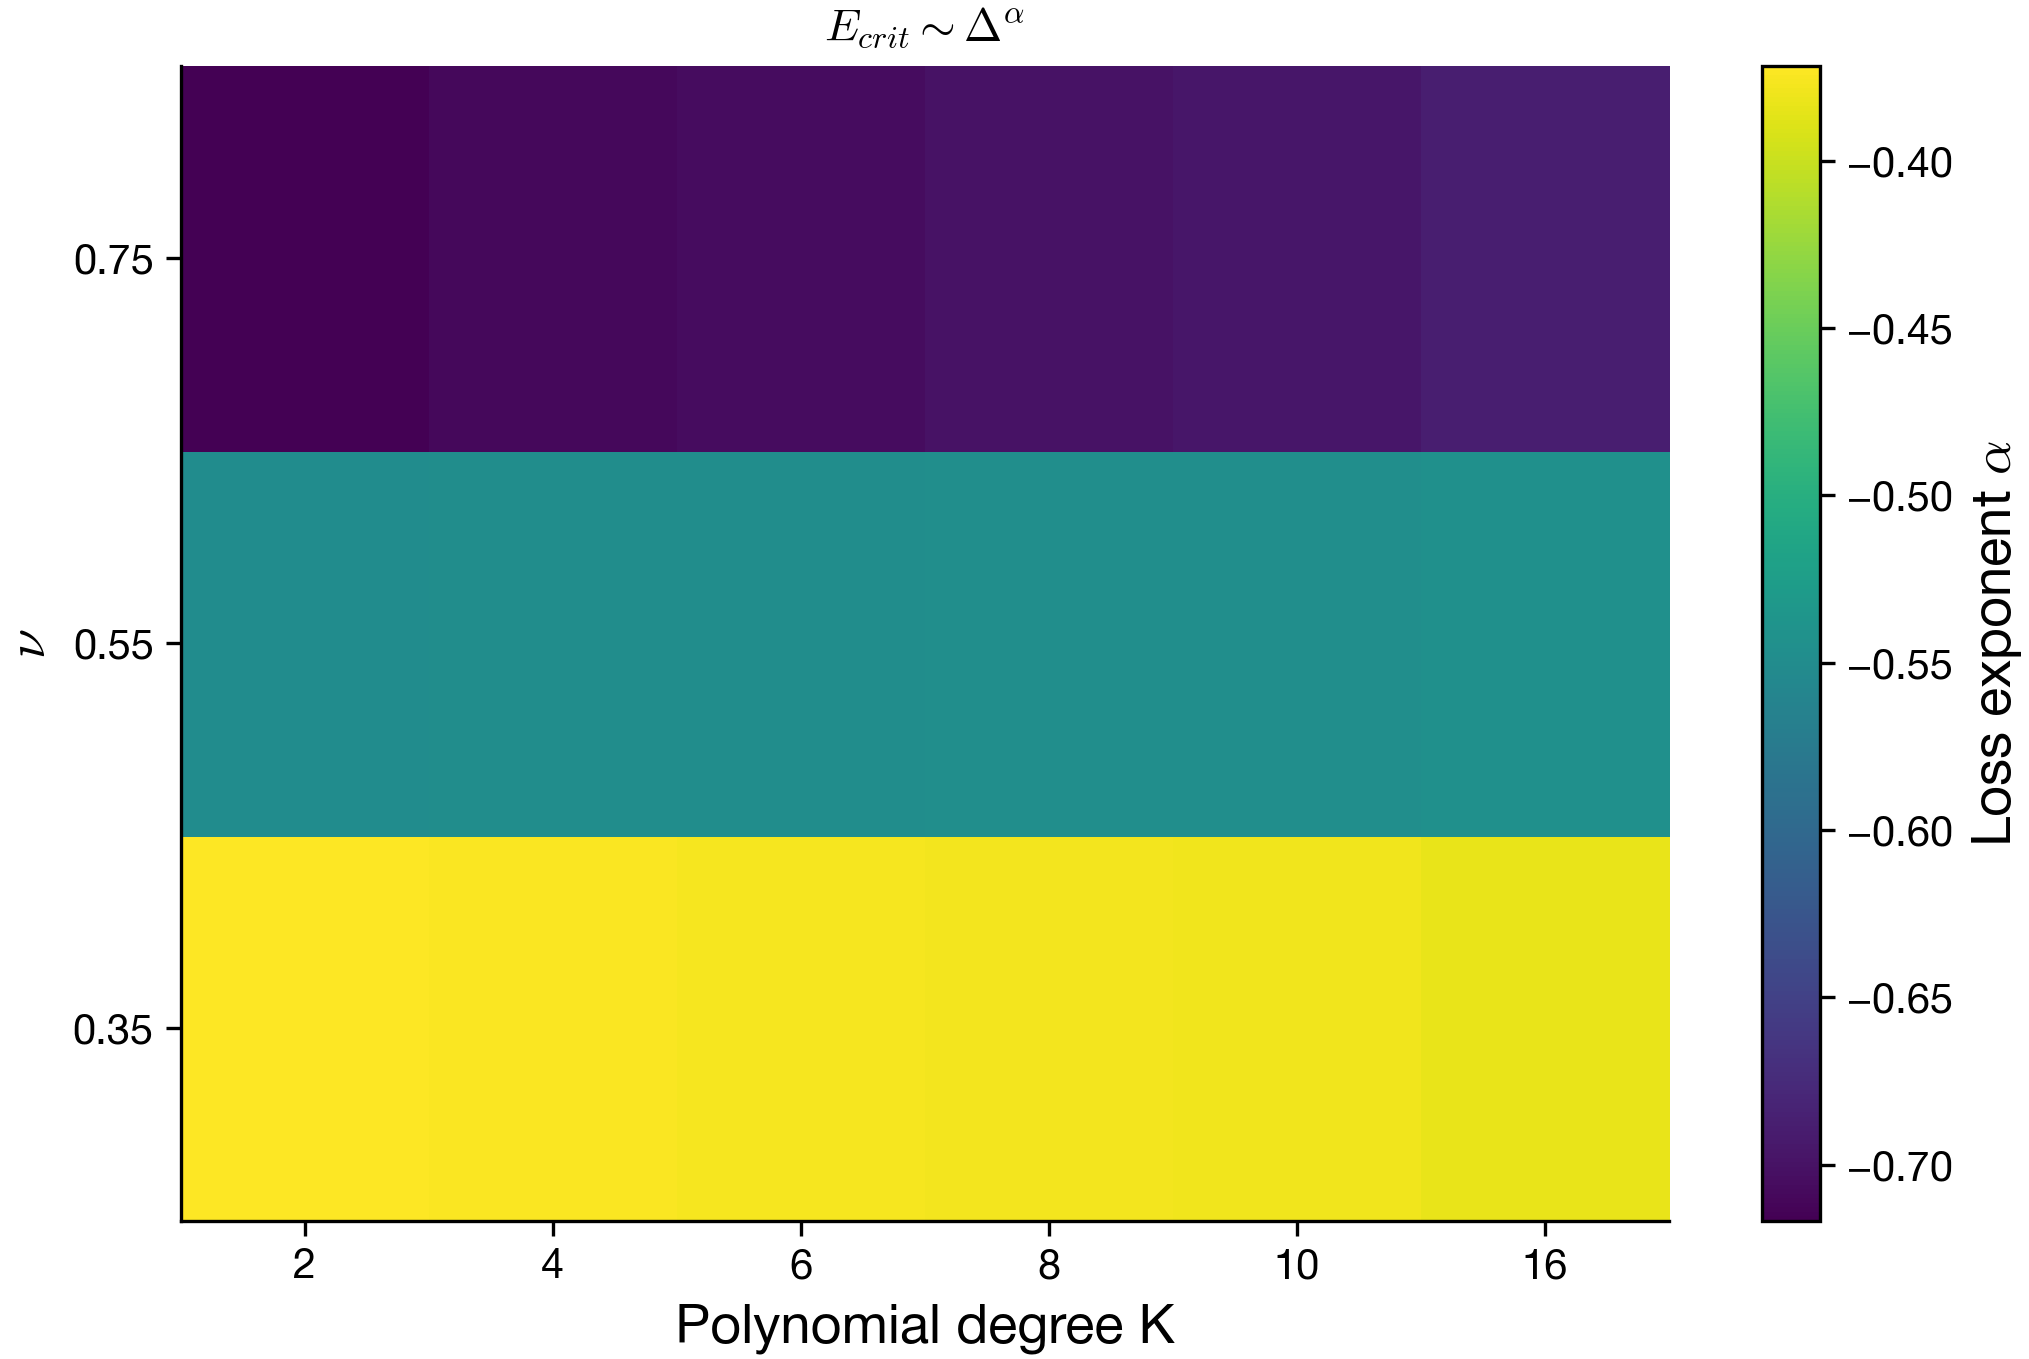

In [ ]:
#@title Loss-Delta power Law exponent

loss_exp = np.zeros(
    (len(nu_list), len(degree_list))
)

for i, nu in enumerate(nu_list):

    for j, degree in enumerate(degree_list):

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(r["critical_mse"])

        xs = np.array(xs)
        ys = np.array(ys)

        mask = ys > 0

        alpha, _ = np.polyfit(
            np.log(xs[mask]),
            np.log(ys[mask]),
            1
        )

        loss_exp[i, j] = alpha

plt.figure(figsize=(8,5), dpi=300)

im = plt.imshow(
    loss_exp,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    im,
    label=r"Loss exponent $\alpha$"
)

plt.xticks(
    np.arange(len(degree_list)),
    degree_list
)

plt.yticks(
    np.arange(len(nu_list)),
    nu_list
)

plt.xlabel("Polynomial degree K")
plt.ylabel(r"$\nu$")
plt.title(
    r"$E_{crit}\sim \Delta^\alpha$"
)
# plt.savefig(f'{fig_folder}/Loss_v_Delta.pdf')
plt.show()

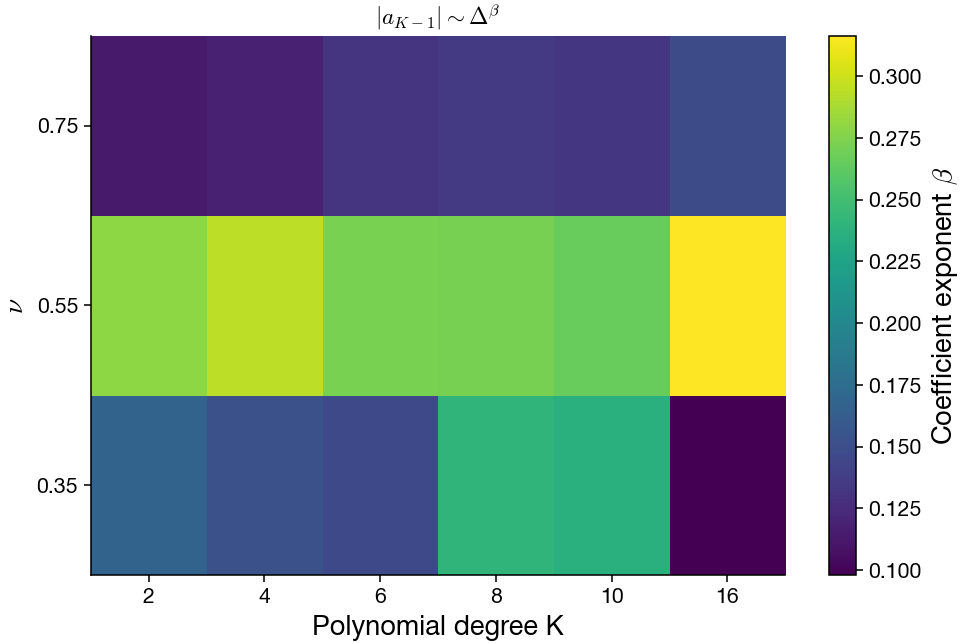

In [34]:
#@title a_{k-1} vs Delta power law exponent

coeff_exp = np.zeros(
    (len(nu_list), len(degree_list))
)

for i, nu in enumerate(nu_list):

    for j, degree in enumerate(degree_list):

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(
                    abs(abs(r["coeffs"][0]))
                )

        xs = np.array(xs)
        ys = np.array(ys)
        lead0 = ys[0]

        corr = np.abs(ys - lead0)

        # mask = ys > 0
        mask = corr > 0

        beta, _ = np.polyfit(
            np.log(xs[mask]),
            np.log(corr[mask]),
            1
        )

        coeff_exp[i, j] = beta

plt.figure(figsize=(8,5))

im = plt.imshow(
    coeff_exp,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    im,
    label=r"Coefficient exponent $\beta$"
)

plt.xticks(
    np.arange(len(degree_list)),
    degree_list
)

plt.yticks(
    np.arange(len(nu_list)),
    nu_list
)

plt.xlabel("Polynomial degree K")
plt.ylabel(r"$\nu$")
plt.title(
    r"$|a_{K-1}|\sim \Delta^\beta$"
)

plt.show()

In [79]:
#@title Testing scaling of inner contribution ( Clenshaw-Curtis Quadrature)

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)
# font = {
#         'weight' : 'light',
#         'size'   : 16}

# mpl.rc('font', **font)
# plt.rc("xtick", labelsize="medium")
# rc = {"mathtext.fontset" : "cm"}
# plt.rcParams.update(rc)

def clenshaw_curtis_nodes_weights(a, b, N):
    """
    Clenshaw-Curtis quadrature on [a,b].

    Returns
    -------
    x : nodes
    w : weights
    """
    if N == 1:
        return np.array([(a+b)/2]), np.array([b-a])

    k = np.arange(N)
    theta = np.pi * k / (N - 1)

    x = np.cos(theta)

    # map to [a,b]
    x = 0.5*(b-a)*x + 0.5*(a+b)

    w = np.zeros(N)

    n = N - 1
    ii = np.arange(1, n)

    v = np.ones(n-1)

    if n % 2 == 0:
        w[0] = 1/(n**2 - 1)
        w[-1] = w[0]

        for j in range(1, n//2):
            v -= 2*np.cos(2*j*theta[ii])/(4*j*j - 1)

        v -= np.cos(n*theta[ii])/(n*n - 1)

    else:
        w[0] = 1/n**2
        w[-1] = w[0]

        for j in range(1, (n+1)//2):
            v -= 2*np.cos(2*j*theta[ii])/(4*j*j - 1)

    w[ii] = 2*v/n

    w *= 0.5*(b-a)

    return x, w




# =====================================================
# Critical function
# =====================================================

def lam(r, nu):
    return np.abs(r) ** (-nu)

def g(r, nu):
    return np.abs(r)**nu/(1.0 + np.abs(r)**nu)

def rho(Delta):
    return 1/(L - Delta)

nu_list = [ 0.35,0.55, 0.75]

Delta_list = np.logspace(-9, 1, 40)

degree_list = [
    6,
    8,
    10
]

# N_quad = 100000
r_min = -1.0
r_max = 1.0

L = r_max-r_min

results = []

for nu in nu_list:
    for Delta in Delta_list:
        for degree in degree_list:



            N_cc = 2000

            rL, wL = clenshaw_curtis_nodes_weights(
                r_min,
                (-Delta/2),
                N_cc
            )

            rR, wR = clenshaw_curtis_nodes_weights(
                (Delta/2),
                r_max,
                N_cc
            )

            r = np.concatenate([rL, rR])
            quad_w = np.concatenate([wL, wR])
            # print(np.sum(quad_w * r**2))

            # dr = r[1] - r[0]


            y_train = g(r, nu)
            weights = 1.0 + lam(r, nu)

            # ---------------------------------
            # basis
            # ---------------------------------

            powers = np.arange(
                0,
                degree + 1,
                2
            )

            nbasis = len(powers)

            # ---------------------------------
            # design matrix
            # ---------------------------------

            Phi = np.column_stack(
                [
                    r**p
                    for p in powers
                ]
            )

            # ---------------------------------
            # M matrix
            # ---------------------------------

            M = (
                Phi.T
                @
                ((rho(Delta) * weights * quad_w)[:,None] * Phi)
            )

            # ---------------------------------
            # b vector
            # ---------------------------------

            b =(
                Phi.T
                @
                ((rho(Delta) * quad_w) )#* y_train)
            )

            # ---------------------------------
            # solve
            # ---------------------------------

            theta = np.linalg.solve(
                M,
                b
            )

            # coefficients
            coeffs_even = theta.copy()

            results.append(
                    {
                        "nu": nu,
                        "Delta": Delta,
                        "degree": degree,

                        "M": M.copy(),
                        "b": b.copy(),
                        "theta": theta.copy(),

                        # "train_mse": train_mse,
                        # "critical_mse": critical_mse
                    }
                          )
        # print(np.sum(quad_w))
        # print(rho(Delta) * np.sum(quad_w))

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


[2.53862897 2.53858683 2.53855248 2.53852438 2.53850126 2.53848197
 2.53846541 2.53845039 2.53843546 2.53841866 2.53839721 2.53836728
 2.53832377 2.53825987 2.53816615 2.53802899 2.53782846 2.53753559
 2.53710834 2.53648598 2.53558102 2.5342681  2.53236866 2.52963029
 2.52569972 2.52008881 2.51213421 2.50095386 2.48540838 2.4640822
 2.43530839 2.39726893 2.34820156 2.28672525 2.21224971 2.1253668
 2.02806886 1.92365141 1.81626549 1.710241  ]
nu=0.35, M00 exponent=0.6584


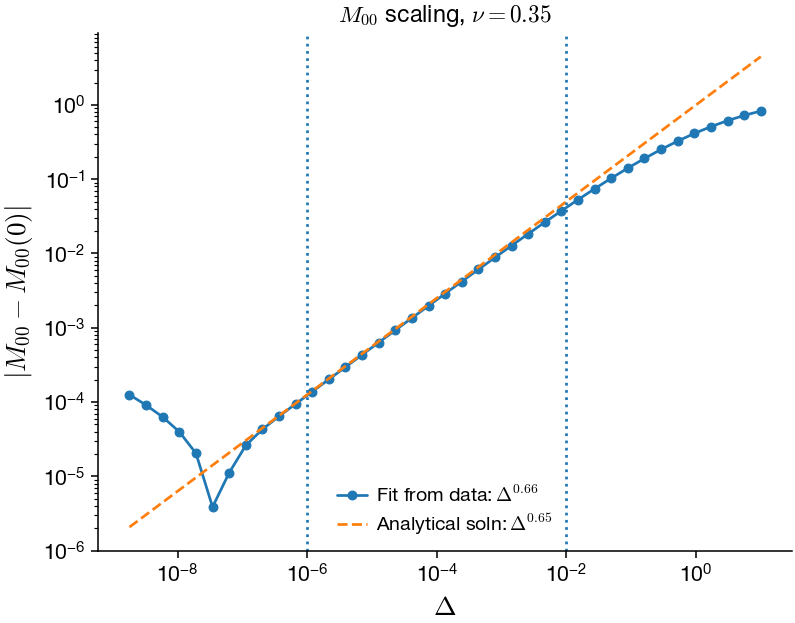

[3.23654372 3.23201487 3.22873984 3.22636945 3.22465013 3.22339646
 3.22247069 3.22176684 3.22119788 3.22068513 3.22015074 3.21951549
 3.21870226 3.21763819 3.21624621 3.21443    3.21206255 3.20897772
 3.20495969 3.19972889 3.1929242  3.18408082 3.17260355 3.1577355
 3.13852343 3.1137828  3.08206897 3.04166608 2.99061214 2.92678698
 2.84809518 2.75277276 2.63982228 2.50952823 2.36392538 2.20702258
 2.04458575 1.8834103  1.73023667 1.59065393]
nu=0.55, M00 exponent=0.4693


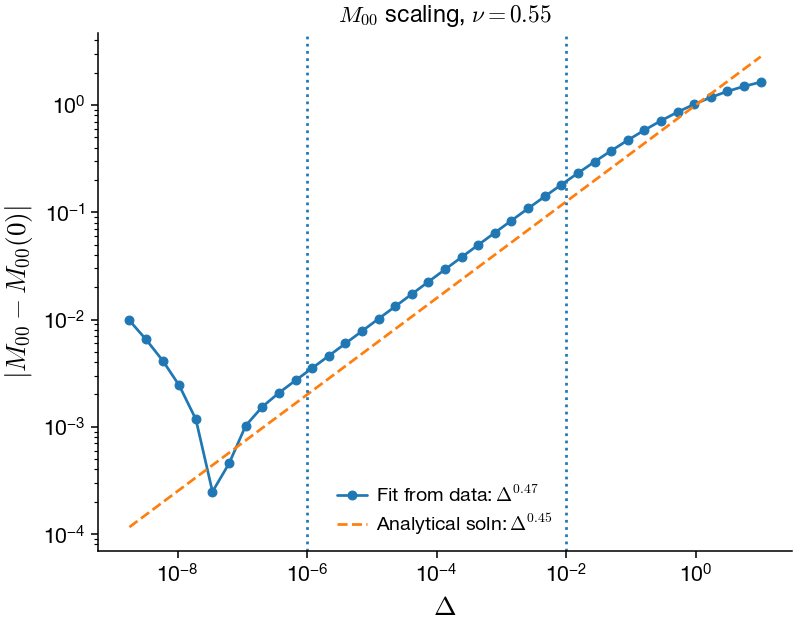

[6.10024718 5.67684347 5.4048779  5.23013748 5.11777825 5.04537563
 4.99844683 4.96755446 4.94642171 4.93070876 4.91726338 4.90376581
 4.88866095 4.87109924 4.85064098 4.8268956  4.79937204 4.76747713
 4.73052116 4.68770835 4.63812332 4.58071728 4.51429566 4.43750997
 4.34885849 4.2467031  4.12931376 3.99495664 3.84204693 3.66938867
 3.4765172  3.26413612 3.03459232 2.79226217 2.54365495 2.29703271
 2.06146058 1.84543897 1.65551547 1.49534878]
nu=0.75, M00 exponent=0.2650


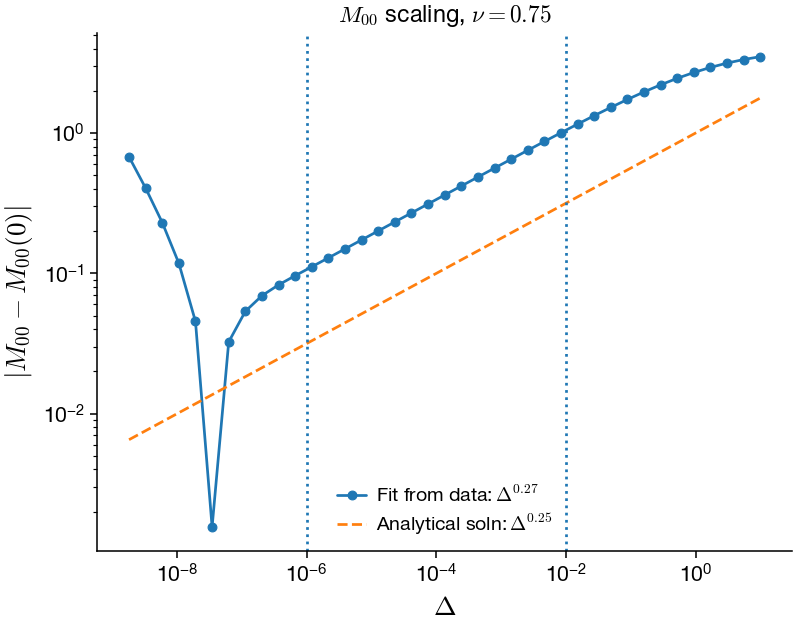

In [100]:
#@title Scaling of M (Clenshaw Quad)


for nu in nu_list:

    degree = 10

    k = 0
    l = 0

    xs = []
    ys = []

    for r in results:

        if (
            np.isclose(r["nu"], nu)
            and r["degree"] == degree
        ):

            xs.append(r["Delta"])
            ys.append(r["M"][k,l])

    order = np.argsort(xs)

    xs = np.array(xs)[order]
    ys = np.array(ys)[order]
    print(ys)

    # estimate asymptotic constant
    # M_inf = ys[0]   # smallest Delta
    # print(M_inf)

    # m0 =  1 + 1**(1-nu+k+l) * 2/(1-nu +k +l)* 1.0/(L - xs)  #Theoretical const coeff
    # print(m0)
    M_inf_exact = 2/L * (1/(2*k + 2*l +1) + 1/(2*k + 2*l + 1 - nu))

    diff = np.abs(ys - M_inf_exact)
    # print(diff)

    mask = np.abs(diff) > 1e-15

    alpha, intercept = np.polyfit(
        # np.log(xs[mask]),
        np.log(xs[7:27]),

        # np.log(diff[mask]),
        np.log(diff[7:27]),

        1
    )

    print(
        f"nu={nu:.2f}, "
        f"M00 exponent={alpha:.4f}"
    )

    plt.figure()

    plt.loglog(
        xs[1:],
        diff[1:],
        marker="o",
        label=fr"Fit from data: $\Delta^{{{alpha:.2f}}}$"
    )

    # plt.loglog(
    #     xs,
    #     np.exp(intercept)*xs**alpha,
    #     "--",
    #     label=fr"$\Delta^{{{alpha:.2f}}}$"
    # )

    plt.loglog(
        xs[1:],
        # np.exp(intercept)*xs**(1.0-nu),
        xs[1:] ** (1.0 - nu),
        "--",
        label=fr"Analytical soln: $\Delta^{{{1.0 - nu:.2f}}}$"
    )

    plt.axvline(1e-6, ls=':')
    plt.axvline(1e-2, ls=':')
    # plt.fill_betweenx(diff[7:27], x1=1e-6, x2=1e-2)

    plt.xlabel(r"$\Delta$")
    plt.ylabel(
        r"$|M_{00}-M_{00}(0)|$"
    )

    plt.title(
        fr"$M_{{00}}$ scaling, $\nu={nu}$"
    )
    if nu == 0.35:
        plt.savefig(f"{fig_folder}/M_v_delta.pdf")
    plt.legend()
    plt.show()

0.3333333333333333
nu=0.35, b_1 exponent=1.0744


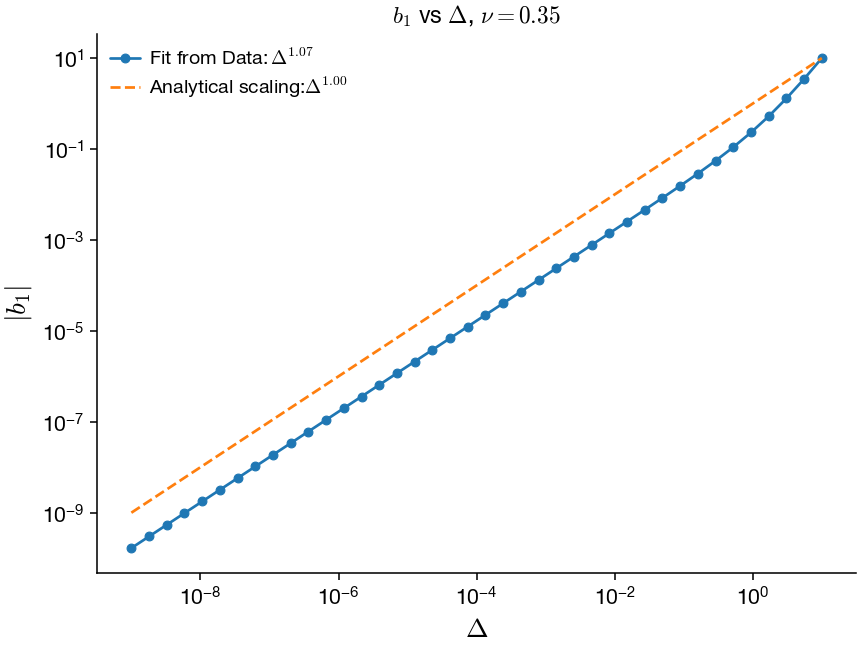

0.3333333333333333
nu=0.55, b_1 exponent=1.0744


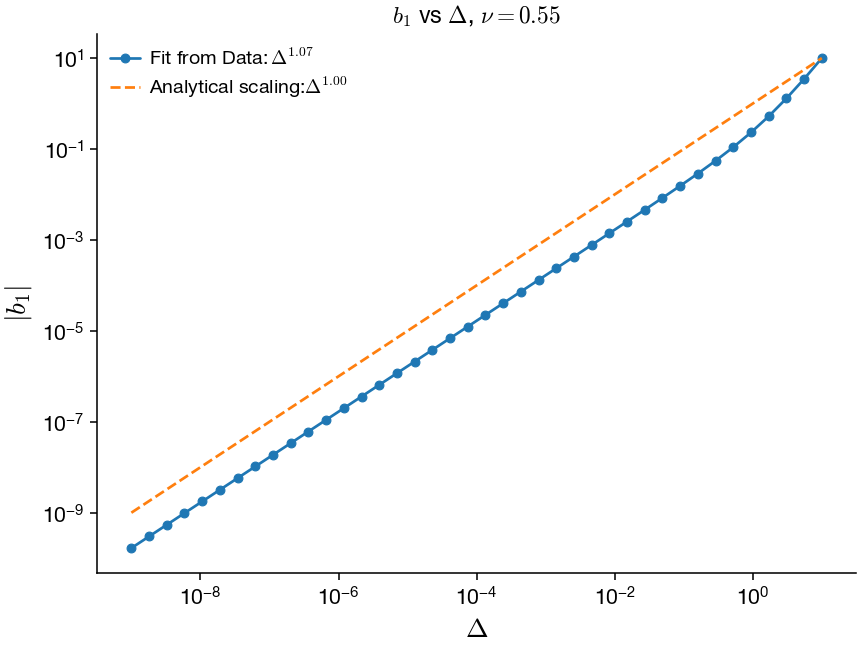

0.3333333333333333
nu=0.75, b_1 exponent=1.0744


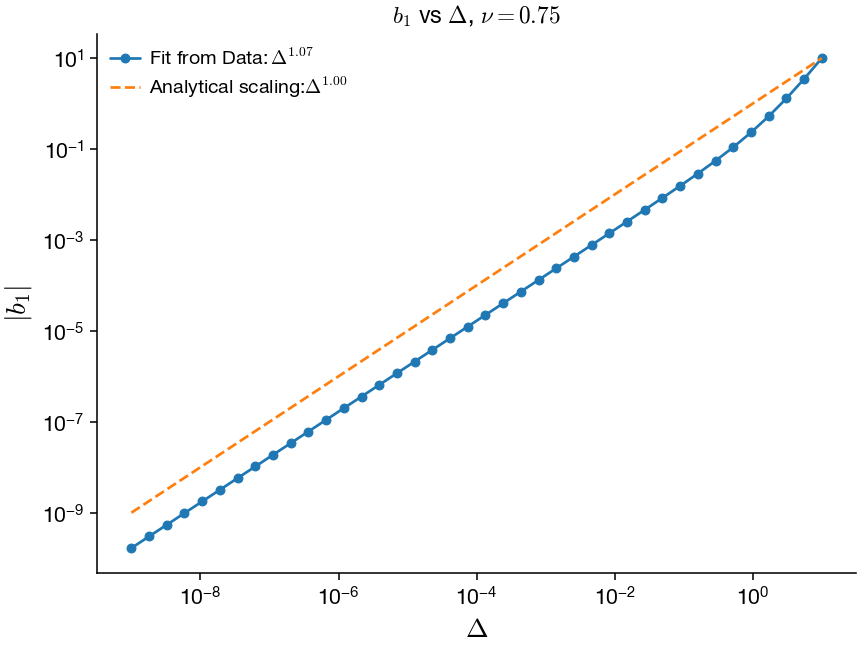

In [118]:
#@title Scaling of b (Clenshaw Quad)
for nu in nu_list:

    plt.figure(figsize=(7,5))

    degree = 10

    k = 1

    xs = []
    ys = []

    for r in results:

        if (
            np.isclose(r["nu"], nu)
            and r["degree"] == degree
        ):

            xs.append(r["Delta"])
            ys.append(r["b"][k])

    order = np.argsort(xs)

    xs = np.array(xs)[order]
    ys = np.array(ys)[order]

    # print(ys)

    # b_inf = ys[0]
    b10 =  2 / (2*k+1)/(L)
    # b10 = 1/(k +1)
    print(b10)

    diff = np.abs(ys - b10)


    mask = (diff > 1e-6)

    alpha, intercept = np.polyfit(
        np.log(xs[mask]),
        # np.log(xs),
        np.log(diff[mask]),
        # np.log(diff),
        1
    )

    print(
        f"nu={nu:.2f}, "
        f"b_{k} exponent={alpha:.4f}"
    )

    plt.loglog(
        xs,
        np.abs(ys - b10),
        marker="o",
        label = fr'Fit from Data: $\Delta^{{{alpha:.2f}}}$'
    )

    # plt.loglog(
    #     xs,
    #     np.exp(intercept)*xs**alpha,
    #     "--",
    #     label=fr"$\Delta^{{{alpha:.2f}}}$"
    # )

    plt.loglog(
        xs,
        xs**1.0,
        "--",
        label=fr"Analytical scaling:$\Delta^{{{1.0:.2f}}}$"
    )

    plt.xlabel(r"$\Delta$")
    plt.ylabel(rf"$|b_{k}|$")
    plt.title(
        fr"$b_{k}$ vs $\Delta$, $\nu={nu}$"
    )
    plt.legend()
    # if nu == 0.35:
        # plt.savefig(f"{fig_folder}/b_v_delta.pdf")
    plt.show()

nu=0.35, theta_0 exponent=0.4947


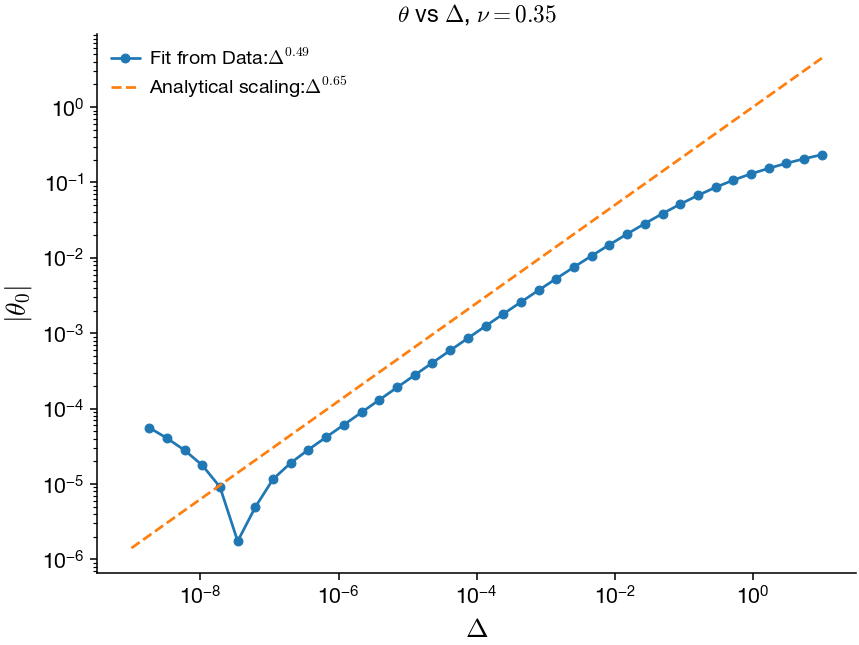

nu=0.55, theta_0 exponent=0.3550


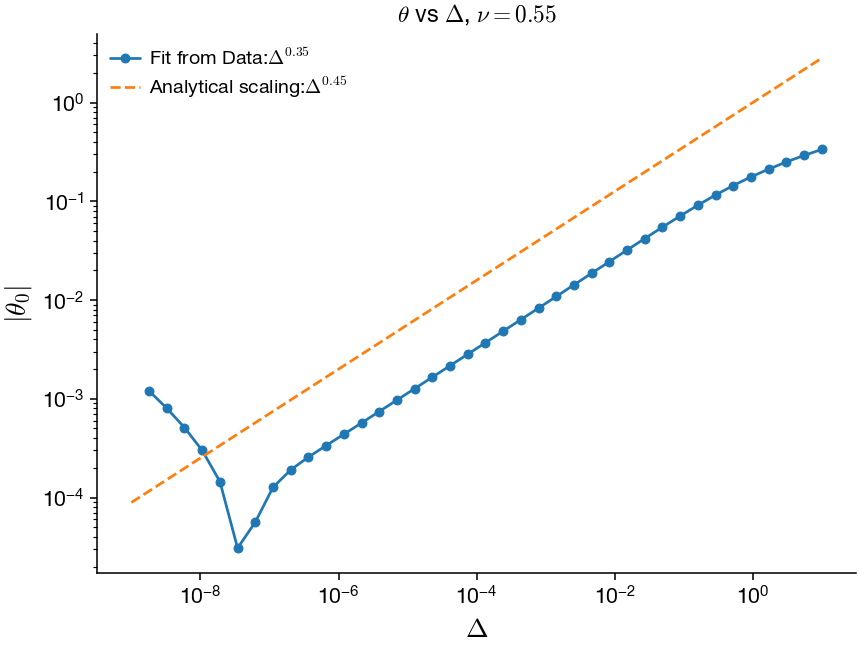

nu=0.75, theta_0 exponent=0.2506


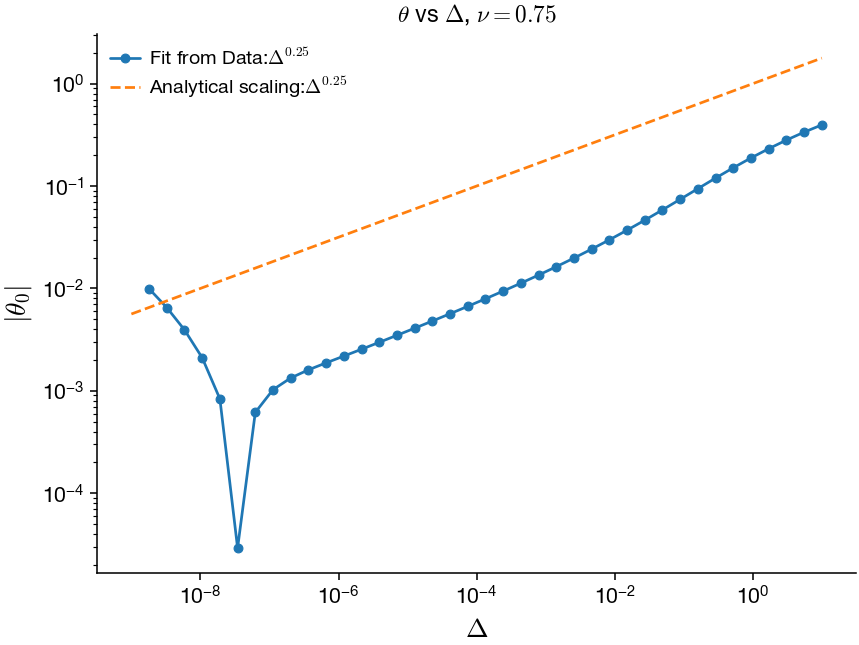

In [116]:
#@title Theta vs Delta
for nu in nu_list:

    powers = np.arange(0, degree+1, 2)
    nbasis = len(powers)

    M0 = np.zeros((nbasis, nbasis))

    for i,k in enumerate(range(nbasis)):
        for j,l in enumerate(range(nbasis)):

            n = 2*k + 2*l

            M0[i,j] = (
                1/(n+1)
                +
                1/(n+1-nu)
            )

    b0 = np.array([
        1/(2*k+1)
        for k in range(nbasis)
    ])

    theta0 = np.linalg.solve(M0, b0)

    plt.figure(figsize=(7,5))

    degree = 10

    k = 0
    l = 0

    xs = []
    ys = []

    for r in results:

        if (
            np.isclose(r["nu"], nu)
            and r["degree"] == degree
        ):

            xs.append(r["Delta"])
            ys.append(r["theta"][k])


    order = np.argsort(xs)

    xs = np.array(xs)[order]
    ys = np.array(ys)[order]


    # print(theta0)

    diff = np.abs(ys - theta0[k])

    mask = (diff > 1e-6)

    alpha, intercept = np.polyfit(
        np.log(xs[mask]),

        np.log(diff[mask]),

        1
    )

    print(
        f"nu={nu:.2f}, "
        f"theta_{k} exponent={alpha:.4f}"
    )

    plt.loglog(
        xs[1:],
        diff[1:],
        marker="o",
        label = fr'Fit from Data:$\Delta^{{{alpha:.2f}}}$'
    )

    # plt.loglog(
    #     xs,
    #     np.exp(intercept)*xs**alpha,
    #     "--",
    #     label=fr"$\Delta^{{{alpha:.2f}}}$"
    # )

    plt.loglog(
        xs,
        xs**(1.0 - nu),
        "--",
        label=fr"Analytical scaling:$\Delta^{{{1.0-nu:.2f}}}$"
    )

    plt.xlabel(r"$\Delta$")
    plt.ylabel(fr"$|\theta_{k}|$")
    plt.title(
        fr"$\theta$ vs $\Delta$, $\nu={nu}$"
    )
    plt.legend()
    # if nu == 0.35:
        # plt.savefig(f"{fig_folder}/theta_v_delta.pdf")
    plt.show()


In [119]:
# @title a_k vs k

for nu in nu_list:

    plt.figure()
    fig, ax = plt.subplots(nrows= 4, ncols=5, figsize = (20, 12), layout = 'constrained')

    for i,delta in enumerate(Delta_list):

        for degree in degree_list:

            xs = []
            ys = []

            for r in results:
            # for degree in degree_list:


                if (
                    r["nu"] == nu
                    and r["degree"] == degree
                    and r["Delta"] == delta
                ):
                    xs.append(r["degree"])
                    ys.append(np.abs(r["theta"]))

                    xvals = np.arange(0, r['degree']+1)

                    ax.flatten()[i].semilogy(
                        np.abs(r["theta"]),
                        '-',
                        marker="o",
                        alpha = 0.7,
                        label=f"K={degree}")
                    # plt.semilogy(
                    #     xvals,
                    #     np.abs(r["coeffs"]),
                    #     marker="o",
                    #     label=f"K={degree}"
                    # )
                    # plt.xticks(xvals)

    fig.suptitle(
        fr"Coeffs vs K (nu={nu})"
    )
    fig.supxlabel(r"Coeffs")
    fig.supylabel("Amplitude")
    plt.legend()
    plt.show()

IndexError: index 20 is out of bounds for axis 0 with size 20

# FINITE SAMPLING NUMERICS

In [170]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# mpl.rcParams.update(mpl.rcParamsDefault)
# font = {
#         'weight' : 'light',
#         'size'   : 16}

# mpl.rc('font', **font)
# plt.rc("xtick", labelsize="medium")
# rc = {"mathtext.fontset" : "cm"}
# plt.rcParams.update(rc)

# =====================================================
# Configuration
# =====================================================

N = [100, 1000, 10000, int(1e+5)]

nu_list = [ 0.55]

Delta_list = np.logspace(-6, 0, 30)

degree_list = [
    6,
    8,
    10,
    20,
    32
]

r_min = -1.0
r_max = 1.0

N_plot = 20000

# =====================================================
# Critical function
# =====================================================

def lam(r, nu):
    return np.abs(r) ** (-nu)

def g(r, nu):
    return np.abs(r)**nu/(1.0 + np.abs(r)**nu)

# =====================================================
# Main sweep
# =====================================================

results = []

for nu in nu_list:

    for Delta in Delta_list:

          for N_train in N:

                # ---------------------------
                # Training samples
                # ---------------------------

                r_left = np.random.uniform(
                    r_min,
                    -Delta/2,
                    N_train // 2
                )

                r_right = np.random.uniform(
                    Delta/2,
                    r_max,
                    N_train // 2
                )

                r_train = np.concatenate(
                    [r_left, r_right]
                )

                y_train = g(r_train, nu)

                # score-loss-inspired weight
                weights = 1.0 + lam(r_train, nu)

                # evaluation grid

                r_plot = np.linspace(
                    r_min,
                    r_max,
                    N_plot
                )

                y_true = g(r_plot, nu)

                train_mask = np.abs(r_plot) > Delta/2
                crit_mask = np.abs(r_plot) < Delta/2

                for degree in degree_list:

                    # -----------------------
                    # Fit polynomial
                    # -----------------------
                    model = make_pipeline(
                        PolynomialFeatures(degree=degree),
                        Ridge(alpha=3.0)
                    )



                    model.fit(r_train[:, None], y_train, ridge__sample_weight = weights)
                    coef = model.named_steps['ridge'].coef_
                    intercept = model.named_steps['ridge'].intercept_
                    ridge = model.named_steps['ridge']

                    # predictions
                    y_pred = model.predict(
                        r_plot[:, None]
                    )

                    poly_coeffs = np.concatenate(
                        [coef[::-1], [intercept]]
                    )


                    plot_weights = 1 + lam(r_plot, nu)

                    # -----------------------
                    # Errors
                    # -----------------------

                    train_mse = np.mean(
                        plot_weights[train_mask] * (
                            y_true[train_mask]
                            - y_pred[train_mask]
                        ) ** 2
                    )

                    r_crit = np.linspace(-Delta/2, Delta/2, N_plot)
                    y_true_crit = g(r_crit, nu)
                    y_pred_crit = model.predict(r_crit[:, None]).ravel()
                    plot_weights_crit = 1.0 + lam(r_crit, nu)

                    critical_mse = np.mean( 
                    plot_weights_crit * (y_true_crit - y_pred_crit) ** 2
                    )

                    # critical_mse = np.mean(
                    #     plot_weights[crit_mask] * (
                    #         g(r_plot[crit_mask], nu)
                    #         - y_pred[crit_mask]
                    #     )**2
                    # )

                    gap_ratio = (
                        critical_mse
                        / train_mse
                    )

                    results.append(
                        {
                            "nu": nu,
                            "Delta": Delta,
                            "degree": degree,
                            "sample_size": N_train,
                            "train_mse": train_mse,
                            "critical_mse": critical_mse,
                            "gap_ratio": gap_ratio,
                            "coeffs": poly_coeffs.copy()
                        }
                    )
                # plt.figure()
                # plt.plot(r_plot,y_true)
                # plt.plot(r_plot, y_pred)
                # # plt.axvspan(-Delta/2,Delta/2, alpha = 0.3, label = 'excised gap')
                # # plt.legend()
                # # plt.xlim(-Delta*100, Delta * 100)
                # plt.xlabel('r')
                # plt.ylabel('g(r)')
                # plt.title(fr'$\Delta$:{Delta:.2e}, $\nu$:{nu:.2e}, K:{degree}')
                # plt.show()

# =====================================================
# Print table
# =====================================================

# for r in results:

#     print(
#         f"nu={r['nu']:4.2f} "
#         f"Delta={r['Delta']:.3e} "
#         f"K={r['degree']:2d} "
#         f"train={r['train_mse']:.3e} "
#         f"critical={r['critical_mse']:.3e} "
#         f"ratio={r['gap_ratio']:.3e}"
#         f"coeff = {r['coeffs']}"
#     )

In [172]:
coef

array([ 1.16490898e-25,  1.14845146e-05,  2.20475378e-01, -7.82477958e-06,
       -1.06434169e-03, -1.81613283e-05, -7.17420381e-02, -1.37969344e-05,
       -4.99954490e-02, -1.48999327e-06, -1.09904911e-02,  9.19755597e-06,
        1.56344620e-02,  1.44486377e-05,  2.58590899e-02,  1.47358845e-05,
        2.43380716e-02,  1.19976528e-05,  1.67817756e-02,  8.02564751e-06,
        7.54773009e-03,  3.92811534e-06, -6.55588620e-04,  1.29020027e-07,
       -6.41995534e-03, -3.45203754e-06, -9.20487898e-03, -7.20242005e-06,
       -8.98966845e-03, -1.16576099e-05, -6.03332840e-03, -1.73902351e-05,
       -7.22454325e-04])

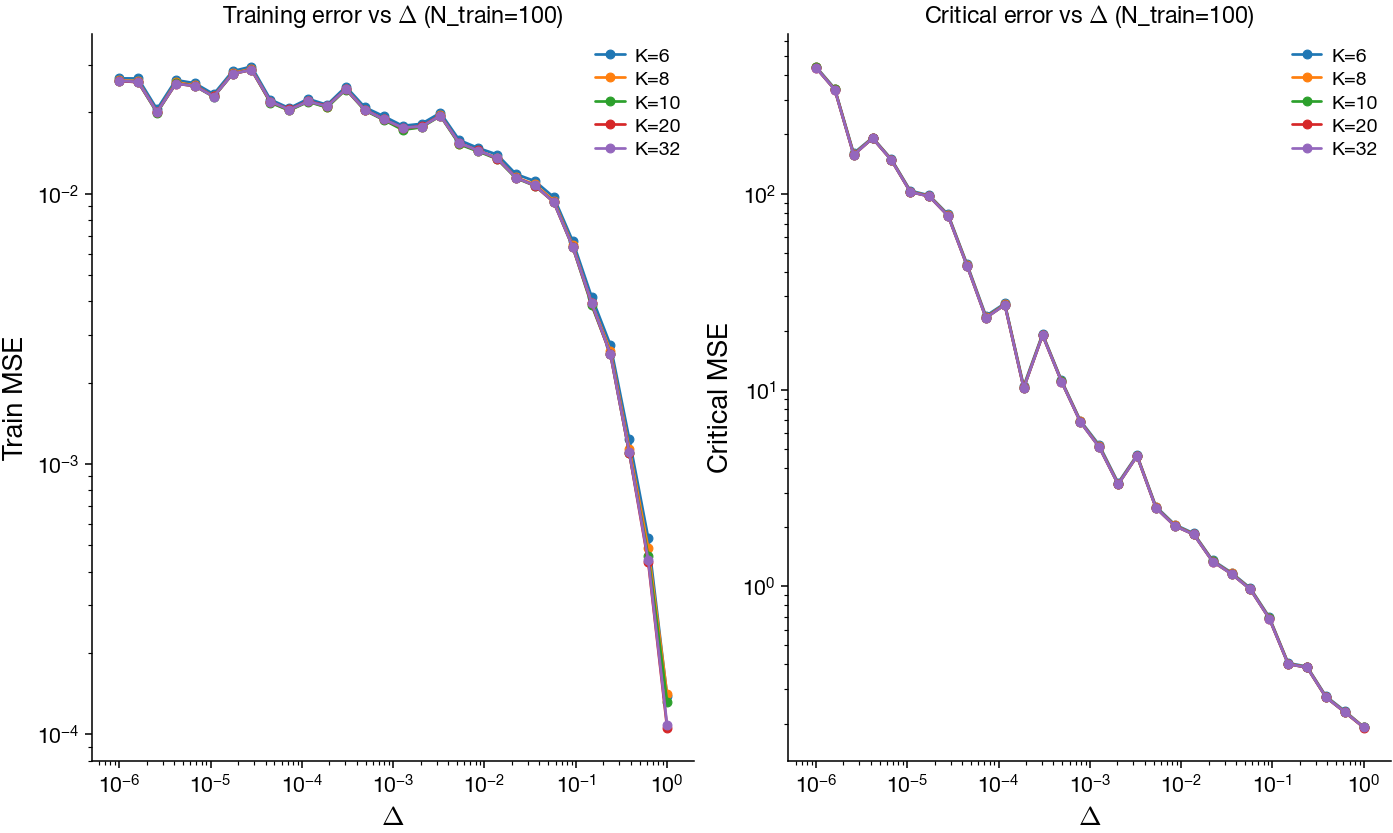

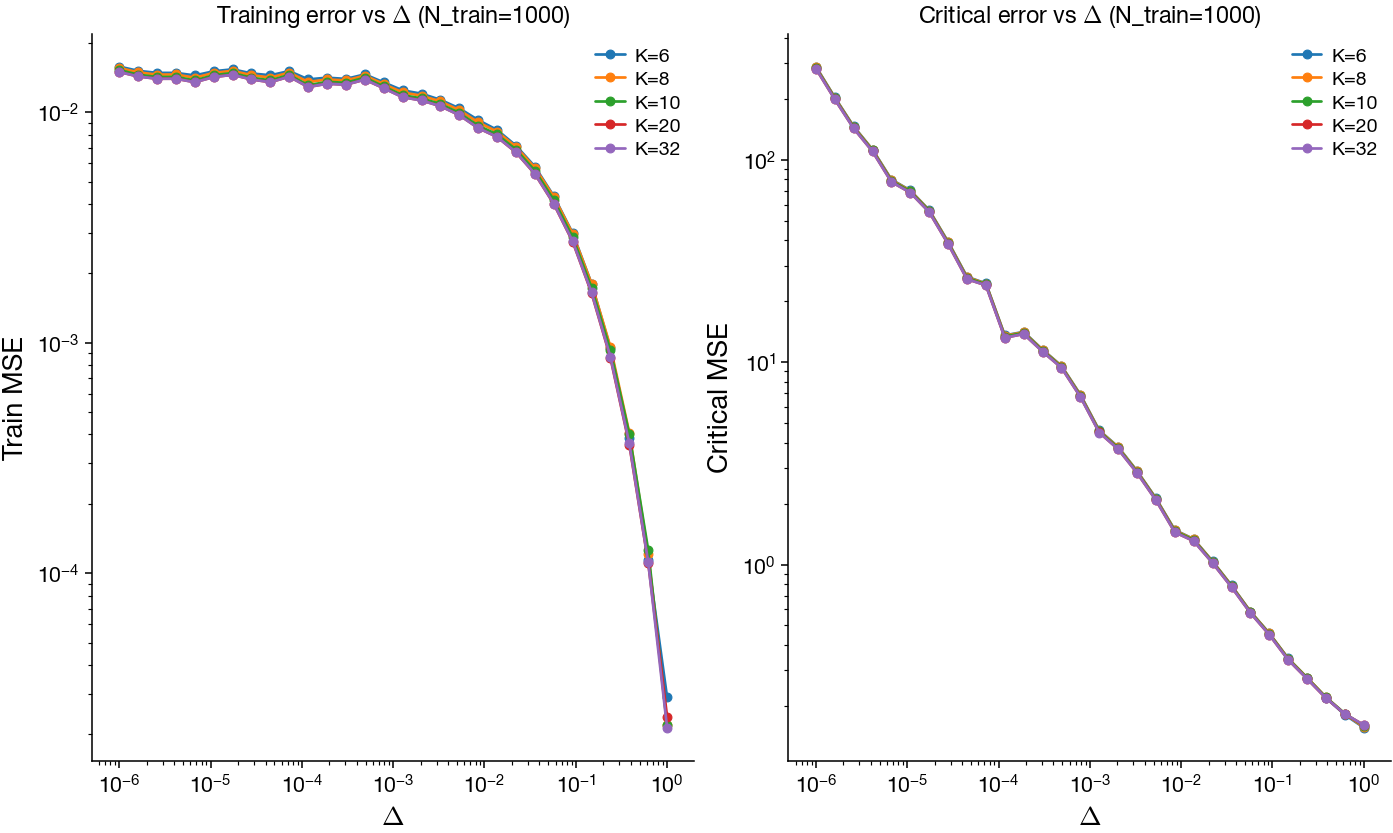

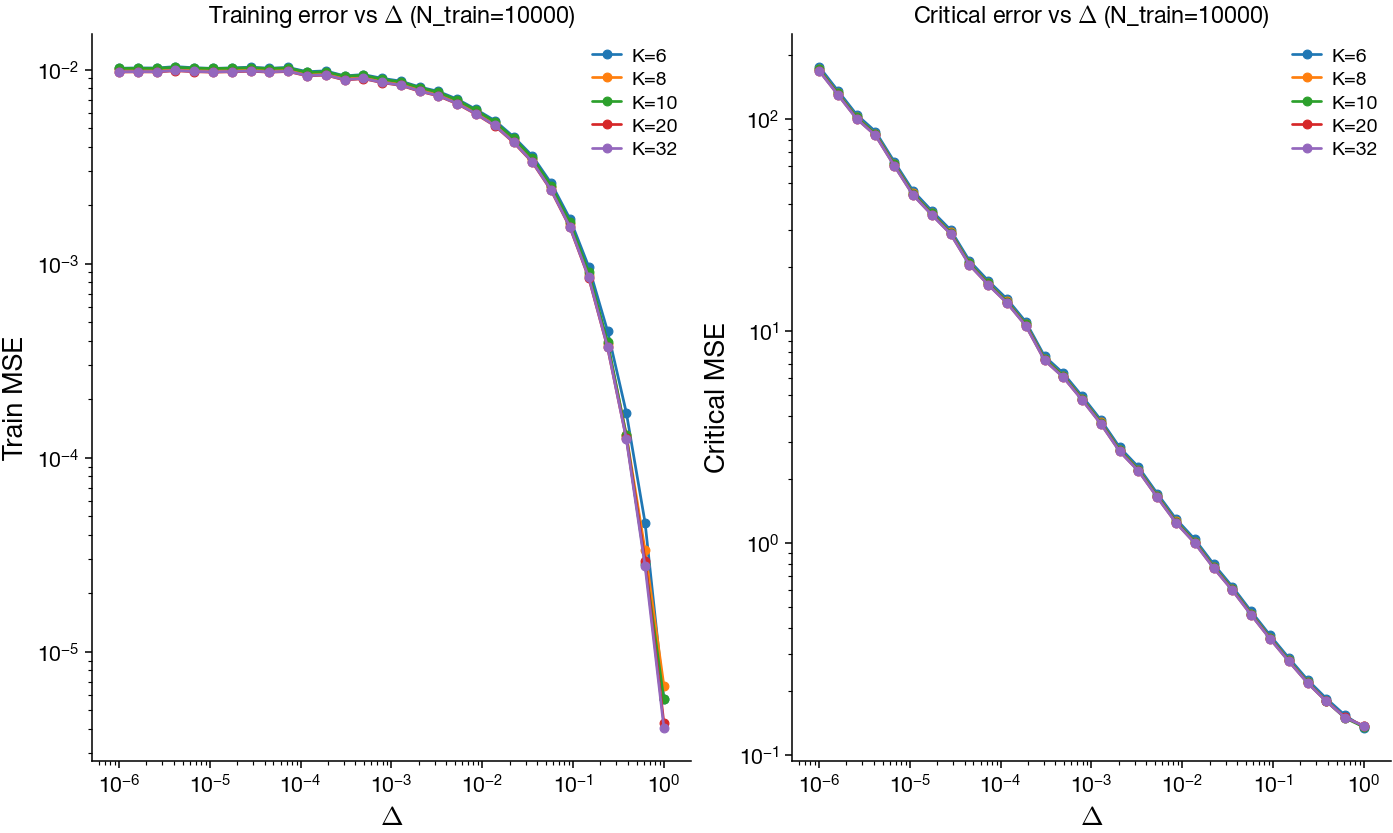

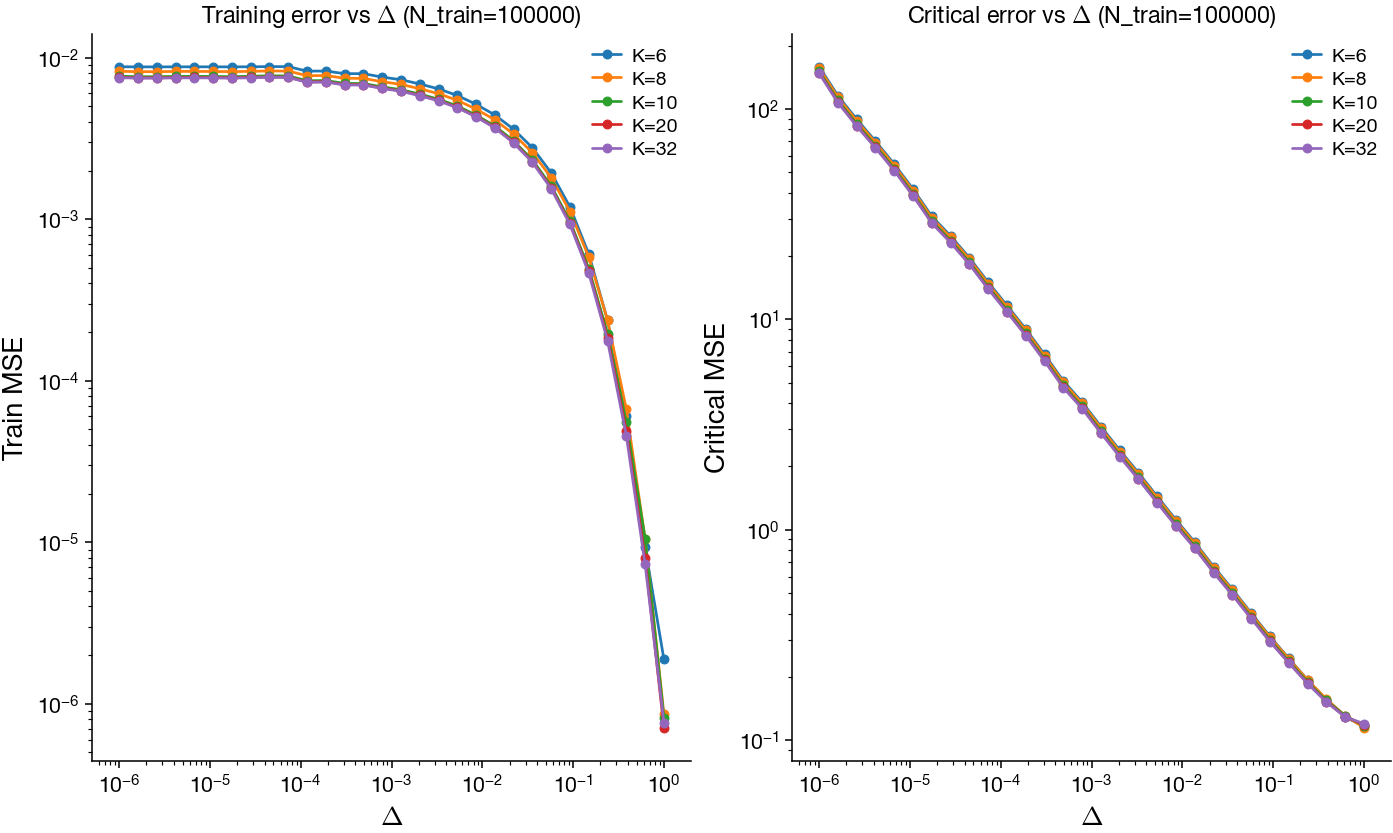

In [173]:
#@title Error vs Delta (Error is calculated in the untrained region only)

for N_train in N:

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize =(10,6), layout = 'constrained')

    for degree in degree_list:

        xs = []
        ys1 = []
        ys2 = []

        for r in results:

            if (
                r["sample_size"] == N_train
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys1.append(r["train_mse"])
                ys2.append(r["critical_mse"])

        ax[0].loglog(
            xs,
            ys1,
            marker="o",
            label=f"K={degree}"
        )
        ax[1].loglog(
            xs,
            ys2,
            marker = "o",
            label = f"K={degree}"
        )

    ax[0].set_title(
        fr"Training error vs $\Delta$ (N_train={N_train})"
    )
    ax[0].set_xlabel(r"$\Delta$")
    ax[0].set_ylabel("Train MSE")

    ax[1].set_title(fr"Critical error vs $\Delta$ (N_train={N_train})")
    ax[1].set_xlabel(r"$\Delta$")
    ax[1].set_ylabel("Critical MSE")

    ax[0].legend()
    ax[1].legend()
    plt.show()

# $\mathcal{L} \text{ vs } N (\Delta \text{= 1e-3, K=8},\nu=0.55)$

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


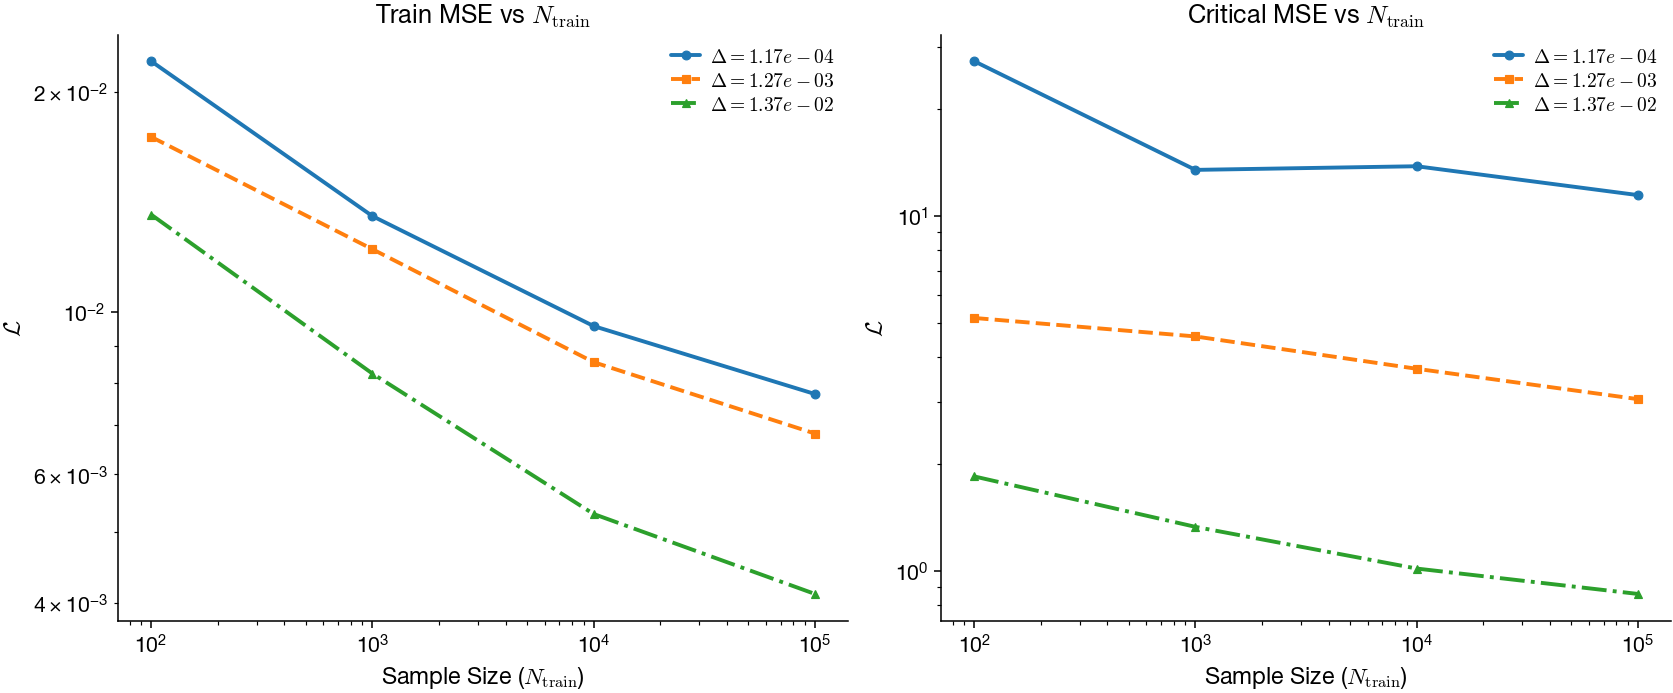

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 1. Select fixed parameters & Delta targets
# -----------------------------------------------------
target_nu = 0.55
target_K = 8
target_deltas = [Delta_list[10], Delta_list[15], Delta_list[20]]

# -----------------------------------------------------
# 2. Side-by-side Plotting
# -----------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')

# Styling options for differentiating Delta curves
markers = ['o', 's', '^']
linestyles = ['-', '--', '-.']

for idx, target_Delta in enumerate(target_deltas):
    # Filter data for current Delta
    filtered_data = [
        item for item in results
        if item['nu'] == target_nu 
        and item['degree'] == target_K 
        and np.isclose(item['Delta'], target_Delta)
    ]

    filtered_data.sort(key=lambda x: x['sample_size'])

    n_train = [item['sample_size'] for item in filtered_data]
    train_mse = [item['train_mse'] for item in filtered_data]
    crit_mse = [item['critical_mse'] for item in filtered_data]

    label_str = fr'$\Delta = {target_Delta:.2e}$'

    # Left Subplot: Train MSE
    ax[0].plot(
        n_train, train_mse, 
        marker=markers[idx], linestyle=linestyles[idx], 
        linewidth=2, label=label_str
    )

    # Right Subplot: Critical MSE
    ax[1].plot(
        n_train, crit_mse, 
        marker=markers[idx], linestyle=linestyles[idx], 
        linewidth=2, label=label_str
    )

# -----------------------------------------------------
# 3. Axis Configuration & Formatting
# -----------------------------------------------------
# Train MSE Subplot
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'Sample Size ($N_{\text{train}}$)', fontsize=12)
ax[0].set_ylabel(r'$\mathcal{L}$', fontsize=12)
ax[0].set_title(r'Train MSE vs $N_{\text{train}}$', fontsize=13)
# ax[0].grid(True, which="both", linestyle="--", alpha=0.5)
ax[0].legend(fontsize=10)

# Critical MSE Subplot
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'Sample Size ($N_{\text{train}}$)', fontsize=12)
ax[1].set_ylabel(r'$\mathcal{L}$', fontsize=12)
ax[1].set_title(r'Critical MSE vs $N_{\text{train}}$', fontsize=13)
# ax[1].grid(True, which="both", linestyle="--", alpha=0.5)
ax[1].legend(fontsize=10)

# Overall Super Title
# fig.suptitle(
#     fr'Performance Comparison Across Multiple $\Delta$ ($K={target_K}$, $\nu={target_nu}$)',
#     fontsize=14
# )
# plt.savefig(f"{fig_folder}/Finite_sample_L_scaling.pdf")
plt.show()

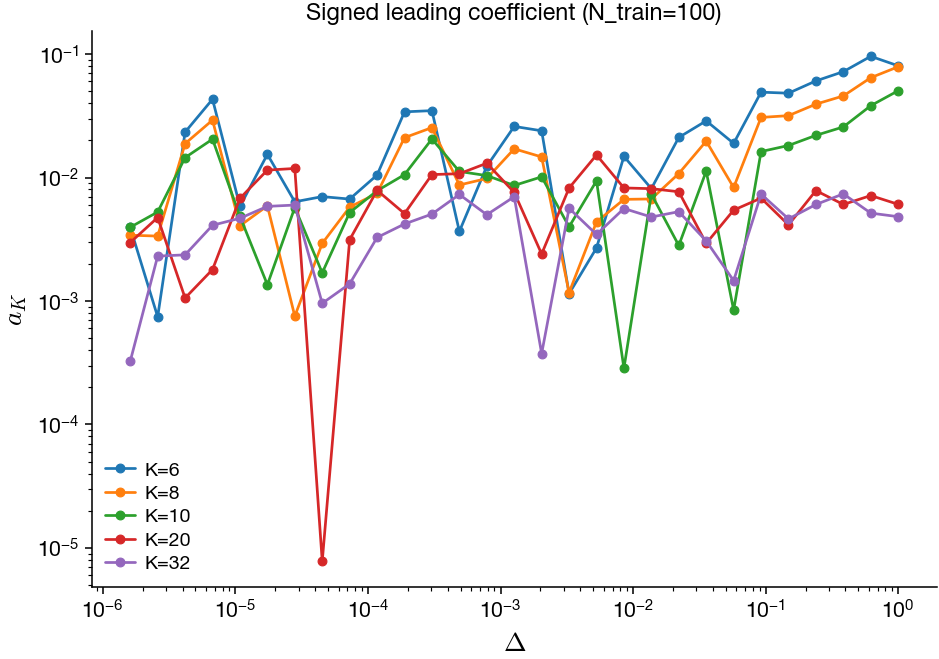

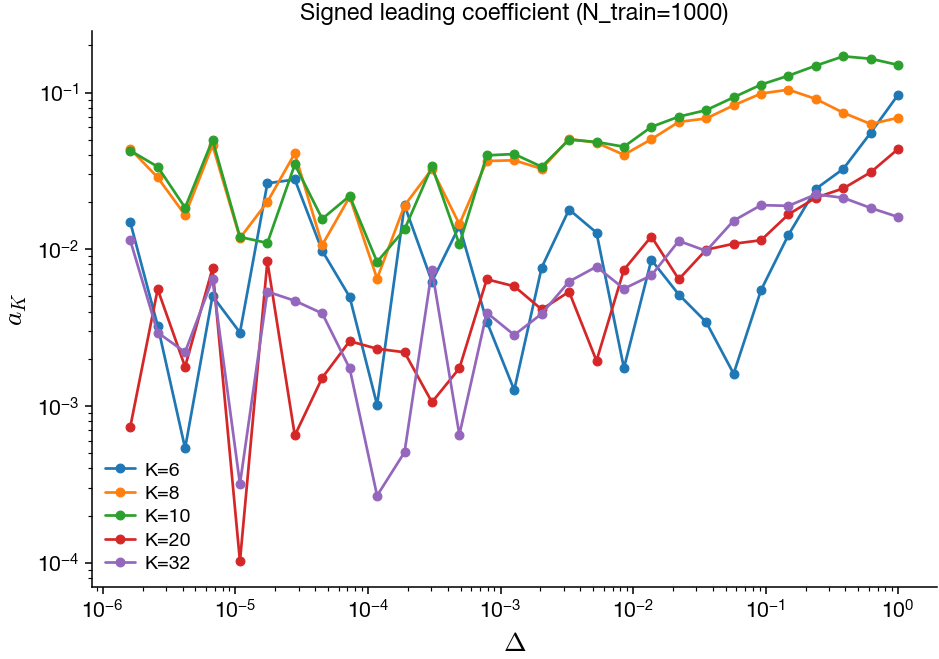

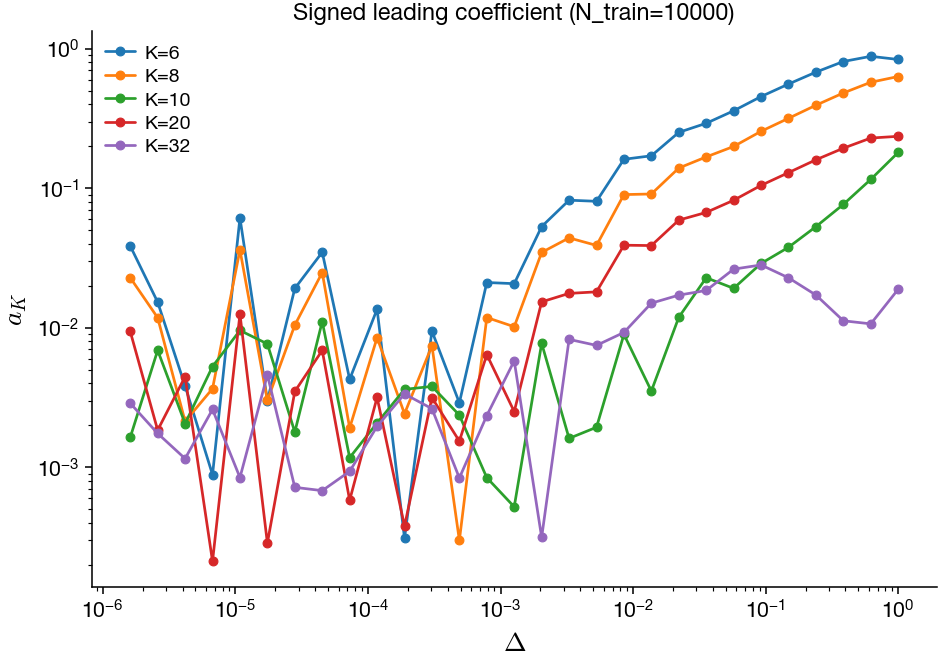

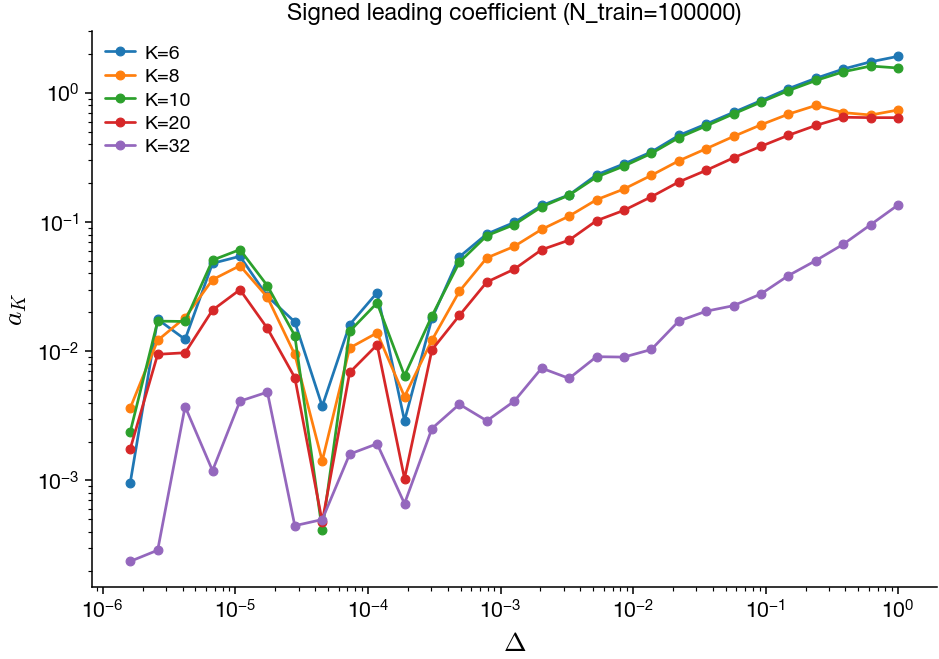

In [123]:
#@title a_k vs Delta

for N_train in N:

    plt.figure(figsize=(7,5))

    for degree in degree_list:

        xs = []
        ys = []

        for r in results:

            if (
                r["sample_size"] == N_train
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(r["coeffs"][0])

        order = np.argsort(xs)

        xs = np.array(xs)[order]
        ys = np.array(np.abs(ys))[order]
        a_inf = ys[0]      # smallest Delta approximation

        corr = np.abs(ys - a_inf)

        plt.loglog(
            xs[1:],
            corr[1:],
            marker="o",
            label=f"K={degree}"
        )

    plt.xlabel(r"$\Delta$")
    plt.ylabel(r"$a_K$")
    plt.title(
        f"Signed leading coefficient (N_train={N_train})"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

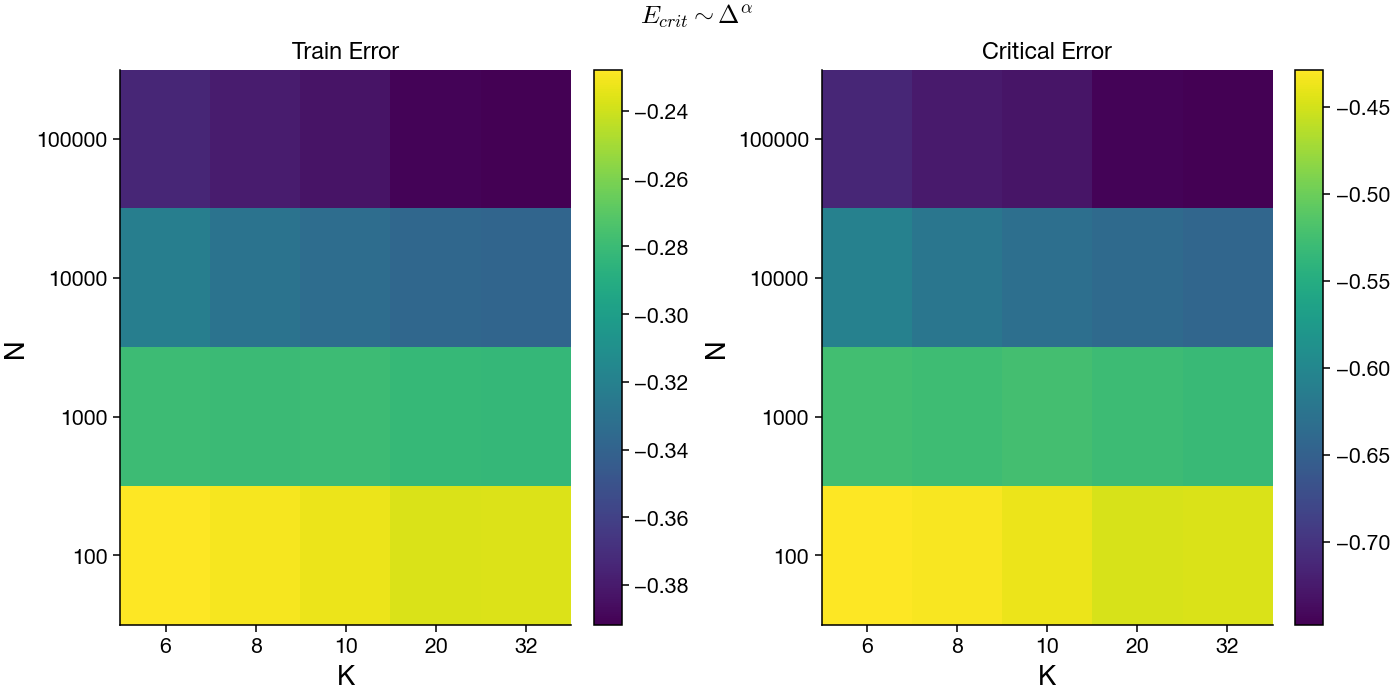

In [124]:
#@title Loss-Delta power Law exponent

loss_exp1 = np.zeros(
    (len(N), len(degree_list))
)
loss_exp2 = np.zeros(
    (len(N), len(degree_list))
)

for i, N_train in enumerate(N):

    for j, degree in enumerate(degree_list):

        xs = []
        ys1 = []
        ys2 = []

        for r in results:

            if (
                r["sample_size"] == N_train
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys1.append(r["train_mse"])
                ys2.append(r["critical_mse"])


        xs = np.array(xs)
        ys1 = np.array(ys1)
        ys2 = np.array(ys2)

        mask1 = ys1 > 0
        mask2 = ys2 > 0

        alpha1, _ = np.polyfit(
            np.log(xs[mask1]),
            np.log(ys1[mask1]),
            1
        )

        loss_exp1[i, j] = alpha1

        alpha2, _ = np.polyfit(
            np.log(xs[mask2]),
            np.log(ys1[mask2]),
            1
        )

        loss_exp2[i, j] = alpha2


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), layout = 'constrained')

im1 = ax[0].imshow(
    loss_exp1,
    aspect="auto",
    origin="lower"
)

im2 = ax[1].imshow(
    loss_exp2,
    aspect= 'auto',
    origin='lower')

# ax[0].colorbar(
#     im1,
#     label=r"Loss exponent $\alpha$"
# )
cbar1 = fig.colorbar(im1, ax= ax[0])
cbar2 = fig.colorbar(im2, ax= ax[1])

ax[0].set_xticks(
    np.arange(len(degree_list)),
    degree_list
)

ax[0].set_yticks(
    np.arange(len(N)),
    N
)
ax[0].set_xlabel("K")
ax[0].set_ylabel("N")
ax[0].set_title("Train Error")


ax[1].set_xticks(
    np.arange(len(degree_list)),
    degree_list
)

ax[1].set_yticks(
    np.arange(len(N)),
    N
)
ax[1].set_xlabel("K")
ax[1].set_ylabel("N")
ax[1].set_title("Critical Error")


fig.suptitle(
    r"$E_{crit}\sim \Delta^\alpha$"
)

plt.show()

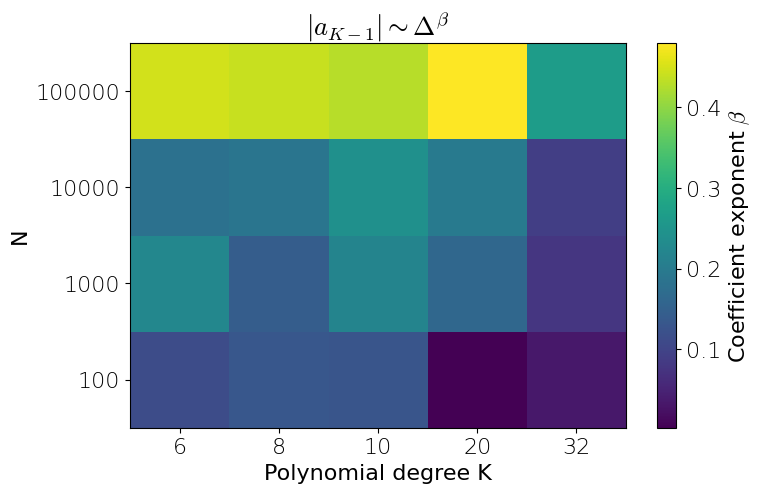

In [57]:
#@title a_{k-1} vs Delta power law exponent

coeff_exp = np.zeros(
    (len(N), len(degree_list))
)

for i, N_train in enumerate(N):

    for j, degree in enumerate(degree_list):

        xs = []
        ys = []

        for r in results:

            if (
                r["sample_size"] == N_train
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(
                    abs(abs(r["coeffs"][0]))
                )

        xs = np.array(xs)
        ys = np.array(ys)
        lead0 = ys[0]

        corr = np.abs(ys - lead0)

        # mask = ys > 0
        mask = corr > 0

        beta, _ = np.polyfit(
            np.log(xs[mask]),
            np.log(corr[mask]),
            1
        )

        coeff_exp[i, j] = beta

plt.figure(figsize=(8,5))

im = plt.imshow(
    coeff_exp,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    im,
    label=r"Coefficient exponent $\beta$"
)

plt.xticks(
    np.arange(len(degree_list)),
    degree_list
)

plt.yticks(
    np.arange(len(N)),
    N
)

plt.xlabel("Polynomial degree K")
plt.ylabel(r"N")
plt.title(
    r"$|a_{K-1}|\sim \Delta^\beta$"
)

plt.show()

# VALIDATION OF ASSUMPTION OF THE COVARIANCE STRUCTURE

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


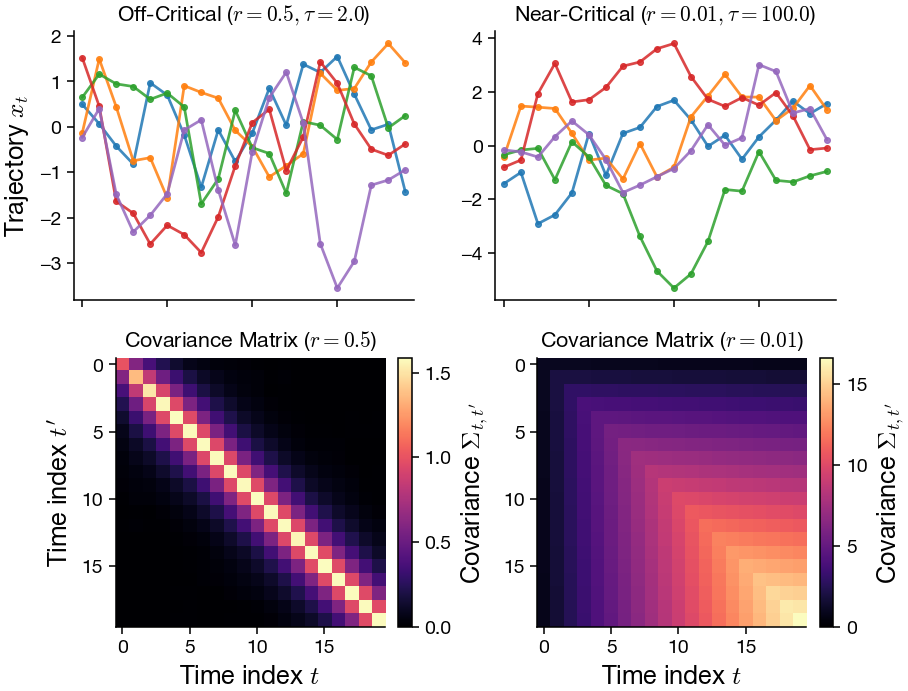

In [62]:
# ==============================================================================
# Figure 1: Sample Trajectories & Covariance Matrices
# ==============================================================================
set_style(base=10)

fig, axes = plt.subplots(2, 2, figsize=(W['prl_double'], 5.2), sharex='col')

# --- Panel 1: Off-critical trajectories ---
np.random.seed(42)
X_far, tau_far = generate_samples(r=0.5, N=5, T=20)
X_near, tau_near = generate_samples(r=0.01, N=5, T=20)

t_axis = np.arange(20)
for i in range(5):
    axes[0, 0].plot(t_axis, X_far[i], alpha=0.85, marker='o', ms=3)
    axes[0, 1].plot(t_axis, X_near[i], alpha=0.85, marker='o', ms=3)

axes[0, 0].set_title(r"Off-Critical ($r=0.5, \tau=2.0$)")
axes[0, 0].set_ylabel(r"Trajectory $x_t$")
axes[0, 1].set_title(r"Near-Critical ($r=0.01, \tau=100.0$)")

# --- Panel 2: Covariance Matrices ---
Sigma_far, _ = covariance(0.5, N=50000, T=20)
Sigma_near, _ = covariance(0.01, N=50000, T=20)

vmax = max(Sigma_far.max(), Sigma_near.max())
im0 = axes[1, 0].imshow(Sigma_far, cmap='magma', origin='upper', vmin=0)
fig.colorbar(im0, ax=axes[1, 0], fraction=0.046, pad=0.04, label=r"Covariance $\Sigma_{t,t'}$")
axes[1, 0].set_title(r"Covariance Matrix ($r=0.5$)")
axes[1, 0].set_xlabel("Time index $t$")
axes[1, 0].set_ylabel("Time index $t'$")

im1 = axes[1, 1].imshow(Sigma_near, cmap='magma', origin='upper', vmin=0)
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04, label=r"Covariance $\Sigma_{t,t'}$")
axes[1, 1].set_title(r"Covariance Matrix ($r=0.01$)")
axes[1, 1].set_xlabel("Time index $t$")

for ax in axes[1, :]:
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(5))

plt.tight_layout()
plt.savefig(f"{fig_folder}/fig1_trajectories_and_covariance.pdf")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


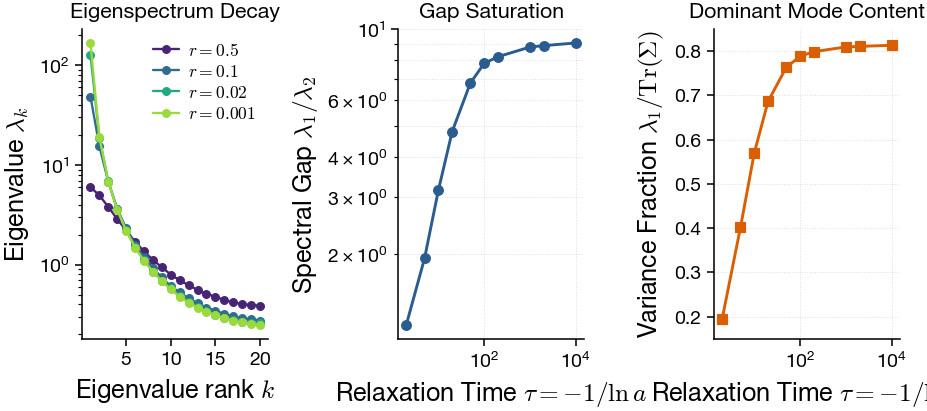

In [ ]:
# ==============================================================================
# Figure 2: Eigenspectrum Decay, Spectral Gap, & Variance Fraction
# ==============================================================================
set_style(base=10)

# Precompute diagnostics over parameter range
r_list = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 5e-3, 1e-3, 5e-4, 1e-4]
taus, lam1_list, lam2_list, gaps, var_fracs = [], [], [], [], []
evecs_dict = {}

for r in r_list:
    Sigma, tau = covariance(r, N=50000, T=20)
    evals, evecs = np.linalg.eigh(Sigma)
    
    lam1 = evals[-1]
    lam2 = evals[-2]
    
    taus.append(tau)
    lam1_list.append(lam1)
    lam2_list.append(lam2)
    gaps.append(lam1 / lam2)
    var_fracs.append(lam1 / np.sum(evals))
    evecs_dict[r] = (evals[::-1], evecs[:, ::-1])  # Sort descending

fig, axes = plt.subplots(1, 3, figsize=(W['prl_double'], 3.2))

# --- Subplot A: Eigenspectrum Decay ---
sample_r = [0.5, 0.1, 0.02, 0.001]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(sample_r)))

for r, color in zip(sample_r, colors):
    evals_desc, _ = evecs_dict[r]
    axes[0].plot(np.arange(1, 21), evals_desc, 'o-', ms=4, lw=1.2, 
                 color=color, label=f"$r={r}$")

axes[0].set_yscale('log')
axes[0].set_xlabel("Eigenvalue rank $k$")
axes[0].set_ylabel(r"Eigenvalue $\lambda_k$")
axes[0].set_title("Eigenspectrum Decay")
axes[0].legend(frameon=False)
axes[0].xaxis.set_major_locator(MultipleLocator(5))

# --- Subplot B: Spectral Gap Ratio ---
axes[1].plot(taus, gaps, 'o-', color='#2b5c8f', lw=1.5, ms=5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r"Relaxation Time $\tau = -1/\ln a$")
axes[1].set_ylabel(r"Spectral Gap $\lambda_1 / \lambda_2$")
axes[1].set_title("Gap Saturation")
axes[1].grid(True, which='both', linestyle=':', alpha=0.4)

# --- Subplot C: Explained Variance Fraction ---
axes[2].plot(taus, var_fracs, 's-', color='#d95f02', lw=1.5, ms=5)
axes[2].set_xscale('log')
axes[2].set_xlabel(r"Relaxation Time $\tau = -1/\ln a$")
axes[2].set_ylabel(r"Variance Fraction $\lambda_1 / \text{Tr}(\Sigma)$")
axes[2].set_title("Dominant Mode Content")
axes[2].set_ylim(0.15, 0.85)
axes[2].grid(True, which='both', linestyle=':', alpha=0.4)

plt.tight_layout()
# plt.savefig(f"{fig_folder}/fig2_spectral_diagnostics.pdf")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


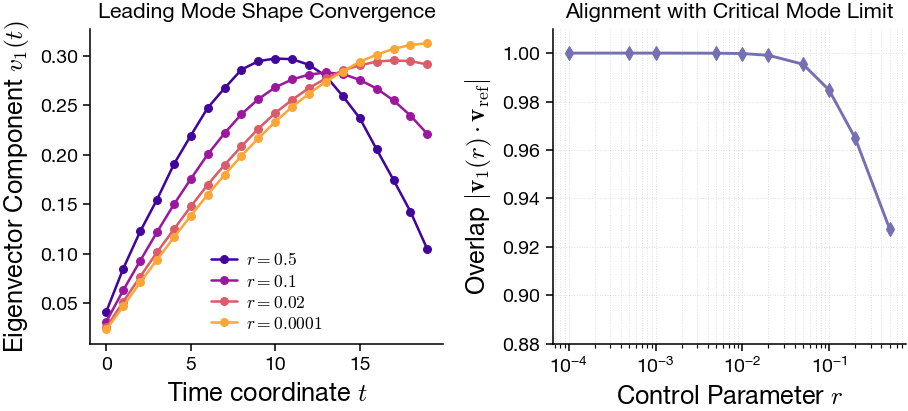

In [ ]:
# ==============================================================================
# Figure 3: Eigenvector Convergence & Vector Overlap
# ==============================================================================
set_style(base=10)

# Reference vector at r = 1e-4
Sigma_ref, _ = covariance(1e-4, N=50000, T=20)
_, evecs_ref = np.linalg.eigh(Sigma_ref)
v_ref = evecs_ref[:, -1]
if v_ref[0] < 0:
    v_ref = -v_ref  # Enforce positive orientation

overlaps = []
for r in r_list:
    Sigma, _ = covariance(r, N=50000, T=20)
    _, evecs = np.linalg.eigh(Sigma)
    v1 = evecs[:, -1]
    if v1[0] < 0:
        v1 = -v1
    overlaps.append(abs(np.dot(v1, v_ref)))

fig, axes = plt.subplots(1, 2, figsize=(W['prl_double'], 3.2))

# --- Panel A: Leading Eigenvector Profile ---
plot_r = [0.5, 0.1, 0.02, 0.0001]
colors = plt.cm.plasma(np.linspace(0.1, 0.8, len(plot_r)))

for r, color in zip(plot_r, colors):
    _, evecs_desc = evecs_dict[r]
    v1 = evecs_desc[:, 0]
    if v1[0] < 0:
        v1 = -v1
    axes[0].plot(np.arange(20), v1, 'o-', ms=4, lw=1.3, color=color, label=f"$r={r}$")

axes[0].set_xlabel("Time coordinate $t$")
axes[0].set_ylabel(r"Eigenvector Component $v_1(t)$")
axes[0].set_title("Leading Mode Shape Convergence")
axes[0].legend(frameon=False)
axes[0].xaxis.set_major_locator(MultipleLocator(5))

# --- Panel B: Alignment Overlap ---
axes[1].plot(r_list, overlaps, 'd-', color='#7570b3', lw=1.5, ms=5)
axes[1].set_xscale('log')
axes[1].set_xlabel(r"Control Parameter $r$")
axes[1].set_ylabel(r"Overlap $|\mathbf{v}_1(r) \cdot \mathbf{v}_{\text{ref}}|$")
axes[1].set_title("Alignment with Critical Mode Limit")
axes[1].set_ylim(0.88, 1.01)
axes[1].grid(True, which='both', linestyle=':', alpha=0.4)

plt.tight_layout()
# plt.savefig(f"{fig_folder}/fig3_eigenvector_alignment.pdf")
plt.show()

# FLUCTUATION ANALYSIS FOR FINITE SAMPLES

In [197]:
# %%
# ==============================================================================
# FINITE-SAMPLE FLUCTUATION ANALYSIS
# ==============================================================================

def get_theta_infinity(Delta, nu, degree, L=1.0, N_cc=2000):
    """
    Computes the exact infinite-sample limit theta_infinity using 
    high-precision Clenshaw-Curtis Quadrature on the excised domain.
    """
    powers = np.arange(0, degree + 1, 2)  # Even powers due to symmetry
    
    rL, wL = clenshaw_curtis_nodes_weights(-L, -Delta / 2.0, N_cc)
    rR, wR = clenshaw_curtis_nodes_weights(Delta / 2.0, L, N_cc)
    
    r = np.concatenate([rL, rR])
    quad_w = np.concatenate([wL, wR])
    
    weights = 1.0 + lam(r, nu)
    rho_val = rho(Delta)
    
    Phi = np.column_stack([r**p for p in powers])
    
    M = Phi.T @ ((rho_val * weights * quad_w)[:, None] * Phi)
    b = Phi.T @ (rho_val * quad_w * g(r, nu))
    
    theta_inf = np.linalg.solve(M, b)
    return theta_inf

In [198]:
# ------------------------------------------------------------------------------
# Ensemble Simulation for Finite Samples
# ------------------------------------------------------------------------------
def run_finite_sample_ensemble(nu, Delta, degree, P_list, S=200, ridge_alpha=1e-8):
    """
    Generates S independent data realizations for each dataset size P in P_list,
    fits the polynomial, and extracts theta_hat and the fluctuation eta.
    """
    theta_inf = get_theta_infinity(Delta, nu, degree)
    
    results_ensemble = {
        'P_list': P_list,
        'var_theta0': [],
        'trace_C': [],
        'C00': [],
        'mean_eta0': []
    }
    
    powers = np.arange(0, degree + 1, 2)
    
    for P in P_list:
        theta_samples = []
        
        for s in range(S):
            # Sample P/2 points from left and right un-excised domains
            r_left = np.random.uniform(-1.0, -Delta / 2.0, P // 2)
            r_right = np.random.uniform(Delta / 2.0, 1.0, P // 2)
            r_train = np.concatenate([r_left, r_right])
            
            y_train = g(r_train, nu)
            weights = 1.0 + lam(r_train, nu)
            
            # Empirical design matrix and weighted fit
            Phi = np.column_stack([r_train**p for p in powers])
            M_hat = (Phi.T @ (weights[:, None] * Phi)) / P
            b_hat = (Phi.T @ (weights * y_train)) / P
            
            # Solve empirical system with slight regularizer for stability
            theta_hat = np.linalg.solve(M_hat + (ridge_alpha / P) * np.eye(len(powers)), b_hat)
            theta_samples.append(theta_hat)
            
        theta_samples = np.array(theta_samples) # Shape: (S, K_even)
        
        # Calculate fluctuations: eta = sqrt(P) * (theta_hat - theta_inf)
        eta_samples = np.sqrt(P) * (theta_samples - theta_inf)
        
        # Empirical Sampling Covariance C = E[eta * eta^T]
        C_matrix = np.cov(eta_samples, rowvar=False)
        
        results_ensemble['var_theta0'].append(np.var(theta_samples[:, 0]))
        results_ensemble['trace_C'].append(np.trace(C_matrix))
        results_ensemble['C00'].append(C_matrix[0, 0])
        results_ensemble['mean_eta0'].append(np.mean(eta_samples[:, 0]))
        
    return results_ensemble

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


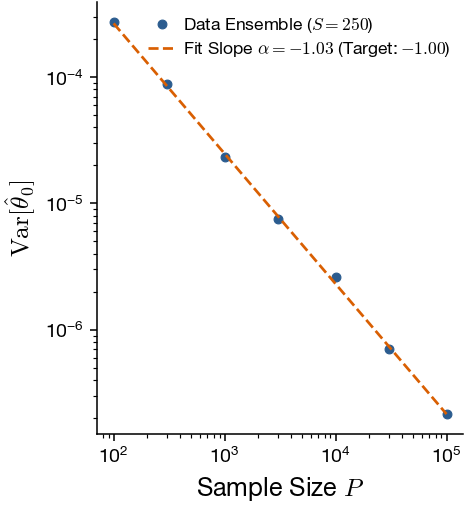

In [ ]:
# %%
# ==============================================================================
# DIAGNOSTIC 1: CLT VERIFICATION (Variance vs P)
# ==============================================================================
set_style(base=10)

target_nu = 0.55
target_K = 16
target_Delta = 1e-2
P_sweep = [100, 300, 1000, 3000, 10000, 30000, 100000]

ens_res = run_finite_sample_ensemble(
    nu=target_nu, 
    Delta=target_Delta, 
    degree=target_K, 
    P_list=P_sweep, 
    S=250
)

# Linear Fit in log-log space to check 1/P scaling
log_P = np.log(P_sweep)
log_var = np.log(ens_res['var_theta0'])
slope, intercept = np.polyfit(log_P, log_var, 1)

fig, ax = plt.subplots(figsize=(W['prl_single'], 4.0))

ax.loglog(P_sweep, ens_res['var_theta0'], 'o', color='#2b5c8f', label=r'Data Ensemble ($S=250$)')
ax.loglog(P_sweep, np.exp(intercept) * np.array(P_sweep)**slope, '--', color='#d95f02', 
          label=fr'Fit Slope $\alpha = {slope:.2f}$ (Target: $-1.00$)')

ax.set_xlabel(r'Sample Size $P$')
ax.set_ylabel(r'$\mathrm{Var}[\hat{\theta}_0]$')
# ax.set_title(fr'CLT Verification ($\Delta={target_Delta}$, $\nu={target_nu}$)')
ax.legend(loc='best',frameon=False)
# ax.grid(True, which='both', linestyle=':', alpha=0.4)

# plt.tight_layout()
# plt.savefig(f"{fig_folder}/clt_verification_variance_vs_P.pdf")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


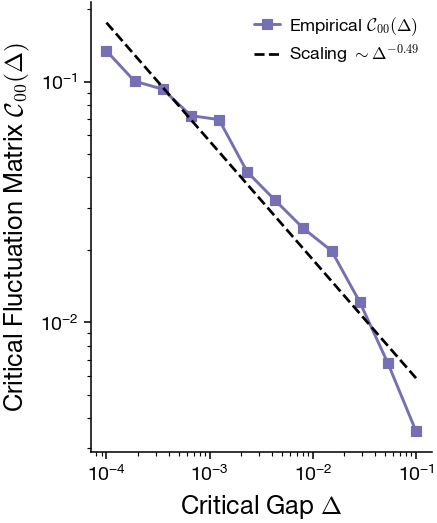

In [212]:
# ==============================================================================
# DIAGNOSTIC 2: NOISE-GAP SCALING (C_00(Delta) vs Delta)
# ==============================================================================
set_style(base=10)

Delta_sweep = np.logspace(-4, -1, 12)
fixed_P = 10000
fixed_S = 200

C00_list = []
trace_C_list = []

for d in Delta_sweep:
    res = run_finite_sample_ensemble(
        nu=target_nu, 
        Delta=d, 
        degree=target_K, 
        P_list=[fixed_P], 
        S=fixed_S
    )
    C00_list.append(res['C00'][0])
    trace_C_list.append(res['trace_C'][0])

# Power-law fit
log_D = np.log(Delta_sweep)
log_C00 = np.log(C00_list)
gamma_slope, gamma_int = np.polyfit(log_D, log_C00, 1)

fig, ax = plt.subplots(figsize=(W['prl_single'], 4.0))

ax.loglog(Delta_sweep, C00_list, 's-', color='#7570b3', lw=1.5, ms=5, 
          label=fr'Empirical $\mathcal{{C}}_{{00}}(\Delta)$')
ax.loglog(Delta_sweep, np.exp(gamma_int) * Delta_sweep**gamma_slope, '--', color='k', 
          label=fr'Scaling $\sim \Delta^{{{gamma_slope:.2f}}}$')

ax.set_xlabel(r'Critical Gap $\Delta$')
ax.set_ylabel(r'Critical Fluctuation Matrix $\mathcal{C}_{00}(\Delta)$')
# ax.set_title(fr'Noise-Gap Scaling ($P={fixed_P}$, $K={target_K}$)')
ax.legend(frameon=False)
# ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.tight_layout()
# plt.savefig(f"{fig_folder}/noise_gap_scaling_C00_vs_Delta.pdf")
plt.show()

/tmp/ipykernel_2562525/1448610713.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{fig_folder}/fig1_spatial_covariance_anisotropy.pdf")
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
/home/kanna/Ananth/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


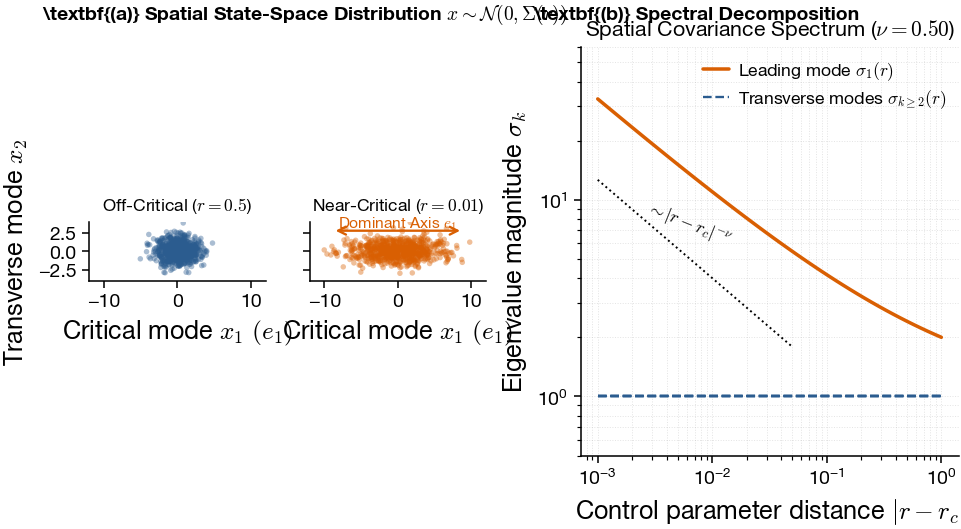

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# ==============================================================================
# Figure 1: Spatial Anisotropy & Spectral Divergence
# ==============================================================================
set_style(base=10)

np.random.seed(42)

# ------------------------------------------------------------------------------
# Data Generation for Panel (a): 2D State Space Scatter
# ------------------------------------------------------------------------------
N_samples = 800
nu_val = 0.50

# Far from criticality (r = 0.5)
r_far = 0.50
sigma1_far = 1.0 + (r_far)**(-nu_val)
sigma2_far = 1.0
cov_far = np.diag([sigma1_far, sigma2_far])
X_far = np.random.multivariate_normal([0, 0], cov_far, size=N_samples)

# Near criticality (r = 0.01)
r_near = 0.01
sigma1_near = 1.0 + (r_near)**(-nu_val)
sigma2_near = 1.0
cov_near = np.diag([sigma1_near, sigma2_near])
X_near = np.random.multivariate_normal([0, 0], cov_near, size=N_samples)

# ------------------------------------------------------------------------------
# Data Generation for Panel (b): Eigenspectrum vs Control Parameter
# ------------------------------------------------------------------------------
d = 5  # Dimensionality of spatial state space
r_axis = np.logspace(-3, 0, 50)  # Reduced distance |r - r_c|
eigenvalues = np.zeros((len(r_axis), d))

for i, r_val in enumerate(r_axis):
    # Dominant mode diverges; transverse modes remain bounded at 1.0
    eigenvalues[i, 0] = 1.0 + (r_val)**(-nu_val)
    eigenvalues[i, 1:] = 1.0

# ------------------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(W['prl_double'], 4.0), layout = 'tight')

# Sub-grid for Panel (a) to keep the two scatter subpanels tightly bound
gs_a = fig.add_gridspec(1, 2, left=0.06, right=0.48, top=0.88, bottom=0.15, wspace=0.25)
ax_a1 = fig.add_subplot(gs_a[0, 0])
ax_a2 = fig.add_subplot(gs_a[0, 1])

# Sub-grid for Panel (b)
gs_b = fig.add_gridspec(1, 1, left=0.58, right=0.98, top=0.88, bottom=0.15)
ax_b = fig.add_subplot(gs_b[0, 0])

# --- Panel (a1): Off-critical scatter ---
ax_a1.scatter(X_far[:, 0], X_far[:, 1], alpha=0.4, color='#2b5c8f', s=8, edgecolors='none')
ax_a1.set_title(r"Off-Critical ($r = 0.5$)", fontsize=9)
ax_a1.set_xlabel(r"Critical mode $x_1 \ (e_1)$")
ax_a1.set_ylabel(r"Transverse mode $x_2$")
ax_a1.set_xlim(-12, 12)
ax_a1.set_ylim(-4, 4)
ax_a1.set_aspect('equal')

# --- Panel (a2): Near-critical scatter ---
ax_a2.scatter(X_near[:, 0], X_near[:, 1], alpha=0.4, color='#d95f02', s=8, edgecolors='none')
ax_a2.set_title(r"Near-Critical ($r = 0.01$)", fontsize=9)
ax_a2.set_xlabel(r"Critical mode $x_1 \ (e_1)$")
ax_a2.set_xlim(-12, 12)
ax_a2.set_ylim(-4, 4)
ax_a2.set_yticklabels([])  # Share Y visual
ax_a2.set_aspect('equal')

# Annotate critical direction orientation
ax_a2.annotate('', xy=(9, 2.8), xytext=(-9, 2.8),
                arrowprops=dict(arrowstyle='<->', color='#d95f02', lw=1.2))
ax_a2.text(0, 3.2, r"Dominant Axis $e_1$", color='#d95f02', fontsize=8, ha='center')

# --- Panel (b): Eigenvalue divergence ---
ax_b.loglog(r_axis, eigenvalues[:, 0], '-', color='#d95f02', lw=1.8, 
            label=r"Leading mode $\sigma_1(r)$")

# Plot transverse modes
for k in range(1, d):
    label_str = r"Transverse modes $\sigma_{k \geq 2}(r)$" if k == 1 else None
    ax_b.loglog(r_axis, eigenvalues[:, k], '--', color='#2b5c8f', lw=1.2, label=label_str)

# Theoretical asymptotic reference slope line
r_ref = np.array([1e-3, 5e-2])
sigma_ref = 0.4 * (r_ref)**(-nu_val)
ax_b.loglog(r_ref, sigma_ref, 'k:', lw=1.0)
ax_b.text(2.5e-3, 6.0, r"$\sim |r - r_c|^{-\nu}$", fontsize=9, rotation=-22)

ax_b.set_xlabel(r"Control parameter distance $|r - r_c|$")
ax_b.set_ylabel(r"Eigenvalue magnitude $\sigma_k$")
ax_b.set_title(r"Spatial Covariance Spectrum ($\nu = 0.50$)")
ax_b.set_ylim(0.5, 60)
ax_b.grid(True, which='both', linestyle=':', alpha=0.35)
ax_b.legend(frameon=False, loc='upper right')

# Axis tweaks
ax_b.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))
ax_b.yaxis.set_major_locator(LogLocator(base=10.0, numticks=4))

# Figure annotations for panel labels
fig.text(0.01, 0.93, r"\textbf{(a)} Spatial State-Space Distribution $x \sim \mathcal{N}(0, \Sigma(r))$", 
         fontsize=10, weight='bold')
fig.text(0.53, 0.93, r"\textbf{(b)} Spectral Decomposition", 
         fontsize=10, weight='bold')

plt.savefig(f"{fig_folder}/fig1_spatial_covariance_anisotropy.pdf")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


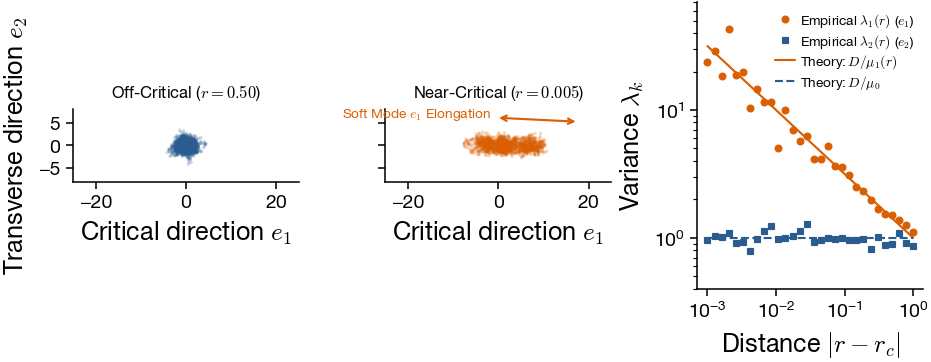

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.ticker import LogLocator

# Set publication style from house style
set_style(base=10)
np.random.seed(42)

# ==============================================================================
# 1. Langevin Process Simulation Function
# ==============================================================================
def simulate_spatial_langevin(r, r_c=0.0, nu=0.5, D=1.0, mu0=1.0, 
                              dt=0.01, T_total=300.0, d=2):
    mu1 = np.abs(r - r_c)**nu
    mus = np.array([mu1] + [mu0]*(d-1))
    
    N_steps = int(T_total / dt)
    x = np.zeros(d)
    burn_in = int(50.0 / dt)
    samples = []
    sqrt_2D_dt = np.sqrt(2.0 * D * dt)
    
    for step in range(N_steps):
        dW = np.random.randn(d)
        x = x - mus * x * dt + sqrt_2D_dt * dW
        if step > burn_in and step % 15 == 0:
            samples.append(x.copy())
            
    return np.array(samples), mus

# Helper function to plot 2D variance confidence ellipses
def add_covariance_ellipse(ax, mean, cov, color, alpha_fill=0.15):
    evals, evecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
    # 2-sigma ellipse (~86% confidence)
    width, height = 2 * 2 * np.sqrt(evals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor=color, alpha=alpha_fill, lw=1.2)
    ax.add_patch(ell)

# ==============================================================================
# 2. Generate Data
# ==============================================================================
X_far, _ = simulate_spatial_langevin(r=0.50)
X_near, _ = simulate_spatial_langevin(r=0.005) # Lowered to r=0.005 for strong critical elongation

r_sweep = np.logspace(-3, 0, 30)
lambda_1_emp, lambda_2_emp = [], []

for r_val in r_sweep:
    X_samples, _ = simulate_spatial_langevin(r=r_val, T_total=250.0)
    Sigma_emp = np.cov(X_samples, rowvar=False)
    evals = np.linalg.eigvalsh(Sigma_emp)
    lambda_2_emp.append(evals[0])
    lambda_1_emp.append(evals[1])

# ==============================================================================
# 3. Visualization
# ==============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(W['prl_double'], 3.2))

plt.subplots_adjust(left=0.08, right=0.98, top=0.82, bottom=0.18, wspace=0.38)

# Fixed coordinate limits across both spatial subpanels for direct visual comparison
x_lims = (-25, 25)
y_lims = (-8, 8)

# --- Subpanel (a1): Off-critical State Space ---
cov_far = np.cov(X_far, rowvar=False)
add_covariance_ellipse(ax1, [0, 0], cov_far, color='#2b5c8f', alpha_fill=0.2)
ax1.scatter(X_far[:, 0], X_far[:, 1], alpha=0.25, color='#2b5c8f', s=3, edgecolors='none')

ax1.set_title(r"Off-Critical ($r = 0.50$)", fontsize=8.5, pad=6)
ax1.set_xlabel(r"Critical direction $e_1$", labelpad=4)
ax1.set_ylabel(r"Transverse direction $e_2$", labelpad=4)
ax1.set_xlim(x_lims)
ax1.set_ylim(y_lims)
ax1.set_aspect('equal')  # Crucial to preserve geometrical aspect ratio

# --- Subpanel (a2): Near-critical State Space ---
cov_near = np.cov(X_near, rowvar=False)
add_covariance_ellipse(ax2, [0, 0], cov_near, color='#d95f02', alpha_fill=0.2)
ax2.scatter(X_near[:, 0], X_near[:, 1], alpha=0.25, color='#d95f02', s=3, edgecolors='none')

ax2.set_title(r"Near-Critical ($r = 0.005$)", fontsize=8.5, pad=6)
ax2.set_xlabel(r"Critical direction $e_1$", labelpad=4)
ax2.set_xlim(x_lims)
ax2.set_ylim(y_lims)
ax2.set_yticklabels([])  # Remove redundant tick labels
ax2.set_aspect('equal')  # Crucial to preserve geometrical aspect ratio

# Soft mode divergence annotation
ax2.annotate(r"Soft Mode $e_1$ Elongation", xy=(18, 5.2), xytext=(-18, 5.2),
             arrowprops=dict(arrowstyle='<->', color='#d95f02', lw=1.1),
             ha='center', va='bottom', color='#d95f02', fontsize=7.0)

# --- Subpanel (b): Spectral Decomposition (Log-Log) ---
ax3.loglog(r_sweep, lambda_1_emp, 'o', color='#d95f02', ms=3.5, 
           label=r"Empirical $\lambda_1(r)$ ($e_1$)")
ax3.loglog(r_sweep, lambda_2_emp, 's', color='#2b5c8f', ms=3.5, 
           label=r"Empirical $\lambda_2(r)$ ($e_2$)")

# Theoretical scaling curves
r_theory = np.logspace(-3, 0, 100)
ax3.loglog(r_theory, 1.0 / (r_theory**0.5), '-', color='#d95f02', lw=1.1, 
           label=r"Theory: $D / \mu_1(r)$")
ax3.loglog(r_theory, np.ones_like(r_theory), '--', color='#2b5c8f', lw=1.1, 
           label=r"Theory: $D / \mu_0$")

ax3.set_xlabel(r"Distance $|r - r_c|$", labelpad=4)
ax3.set_ylabel(r"Variance $\lambda_k$", labelpad=4)
# ax3.set_title(r"Covariance Spectrum", fontsize=8.5, pad=6)
ax3.set_ylim(0.4, 70)

ax3.legend(frameon=False, loc='upper right', fontsize=7.0, handletextpad=0.3, labelspacing=0.2)

ax3.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))
ax3.yaxis.set_major_locator(LogLocator(base=10.0, numticks=4))

# Section titles using Mathtext bold syntax
# fig.text(0.08, 0.92, r"$\mathbf{(a)}$ State-Space Trajectories", fontsize=9.5, va='bottom')
# fig.text(0.68, 0.92, r"$\mathbf{(b)}$ Spectrum", fontsize=9.5, va='bottom')

plt.savefig(f"{fig_folder}/fig1_langevin_derived_covariance.pdf")
plt.show()